In [19]:
# Import essential libraries
import pandas as pd
import numpy as np
import pyreadstat
import os

# local thesis data folder
rawdata = "C:/Users/nikol/Desktop/Thesis_Data/"
results = "./results/"

os.makedirs(results, exist_ok=True)
print("Path updated successfully!")

Path updated successfully!


In [20]:
# Load the 2003 Q1 SPSS file
file_path = os.path.join(rawdata, "LFS_PUF_2003A.sav")
df, meta = pyreadstat.read_sav(file_path)

# Convert all column names to lowercase 
df.columns = df.columns.str.lower()

# Preview the first few rows
df.head()

,household_nr,atomo,trimino,a03,a04,a05,a06,a07,a10,a11_r,...,e81,e82,katap,ypa_r,ast_r3n,age5,age,or_rr,durune,weig1000
0,1.0,01,2003A,1,99,99,99,2,1,1,...,,,3,01,3,15-19,19,,,113.16
1,2.0,01,2003A,1,02,99,99,1,3,2,...,,,3,01,3,65-69,67,,,102.90
2,2.0,02,2003A,2,01,99,99,2,3,2,...,,,3,01,3,50-54,51,,,118.26
3,3.0,01,2003A,1,99,99,99,2,2,3,...,,,3,01,3,75+,83,,,91.70
4,4.0,01,2003A,1,99,99,99,1,1,3,...,,,1,01,3,35-39,36,50,,141.56


In [21]:
import pandas as pd
import numpy as np
import pyreadstat
import os

years = [2003, 2004, 2005]
quarters = ['A', 'B', 'C', 'D']
rawdata = "C:/Users/nikol/Desktop/Thesis_Data/"

all_frames = []

for y in years:
    for q in quarters:
        file_path = os.path.join(rawdata, f"LFS_PUF_{y}{q}.sav")
        
        # Check if the file exists before trying to read it
        if not os.path.exists(file_path):
            print(f"Skipping missing file: {file_path}")
            continue
            
        print(f"Processing year {y}, quarter {q}...")
        
        # Read SPSS file
        df, meta = pyreadstat.read_sav(file_path)
        df.columns = df.columns.str.lower()
        
        # --- 1. Year and Quarter ---
        df['year'] = y
        q_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4}
        df['quarter'] = q_map.get(q.lower())
        
        # --- 2. Demographics ---
        df['age'] = pd.to_numeric(df['age'], errors='coerce')
        df['female'] = np.where(df['a07'].astype(str).str.contains('2'), 1, 0)
        
        # --- 3. Education Level (edulevel mapping from e63_2) ---
        if 'e63_2' in df.columns:
            e63 = df['e63_2'].astype(str).str.strip()
            df['edulevel'] = np.select(
                [
                    e63.isin(['0', '1']),
                    e63 == '2',
                    e63 == '3',
                    e63 == '4',
                    e63 == '5',
                    e63.isin(['6', '7'])
                ],
                [1, 2, 3, 4, 5, 6],
                default=np.nan
            )
        
        # --- 4. Harmonized Salary Brackets (e78) ---
        if 'e78' in df.columns:
            raw_sal = pd.to_numeric(df['e78'], errors='coerce')
            salary_cont = np.nan
            
            if y == 2003:
                raw_sal = np.where(raw_sal.isin([9, 10]), np.nan, raw_sal)
                sal_map = {1: 250, 2: 376, 3: 626, 4: 876, 5: 1126, 6: 1376, 7: 1626, 8: 1876}
                salary_cont = pd.Series(raw_sal).map(sal_map)
            elif y in [2004, 2005]:
                raw_sal = np.where(raw_sal == 10, np.nan, raw_sal)
                sal_map = {1: 250, 2: 376, 3: 626, 4: 876, 5: 1126, 6: 1376, 7: 1626, 8: 1876, 9: 2251}
                salary_cont = pd.Series(raw_sal).map(sal_map)
                
            df['salary_cont'] = salary_cont

        # --- 5. Region and Weights ---
        if 'ypa_r' in df.columns:
            df['nuts2'] = pd.to_numeric(df['ypa_r'], errors='coerce')
        if 'weig1000' in df.columns:
            df['weightq'] = pd.to_numeric(df['weig1000'], errors='coerce')

        all_frames.append(df)

# Combine all quarters into one master dataframe 
master_df_03_05 = pd.concat(all_frames, ignore_index=True)
print(" Harmonized dataset created successfully. Total rows:", master_df_03_05.shape[0])

Processing year 2003, quarter A...
Processing year 2003, quarter B...
Processing year 2003, quarter C...
Processing year 2003, quarter D...
Processing year 2004, quarter A...
Processing year 2004, quarter B...
Processing year 2004, quarter C...
Processing year 2004, quarter D...
Processing year 2005, quarter A...
Processing year 2005, quarter B...
Processing year 2005, quarter C...
Processing year 2005, quarter D...
 Harmonized dataset created successfully. Total rows: 929938


In [22]:
# --- 2006–2007 HARMONIZATION LOOP ---
years_06_07 = [2006, 2007]
all_frames_06_07 = []

for y in years_06_07:
    for q in quarters:
        file_path = os.path.join(rawdata, f"LFS_PUF_{y}{q}.sav")
        
        if not os.path.exists(file_path):
            print(f"Skipping missing file: {file_path}")
            continue
            
        print(f"Processing year {y}, quarter {q}...")
        
        df, meta = pyreadstat.read_sav(file_path)
        df.columns = df.columns.str.lower()
        
        # --- 1. Year and Quarter ---
        df['year'] = y
        q_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4}
        df['quarter'] = q_map.get(q.lower())
        
        # --- 2. Demographics ---
        df['age'] = pd.to_numeric(df['age'], errors='coerce')
        df['female'] = np.where(df['a07'].astype(str).str.contains('2'), 1, 0)
        
        # --- 3. Education Level (edulevel mapping from e80_2 for 2006-2007) ---
        if 'e80_2' in df.columns:
            e80 = df['e80_2'].astype(str).str.strip()
            df['edulevel'] = np.select(
                [
                    e80.isin(['0', '1']),
                    e80 == '2',
                    e80 == '3',
                    e80 == '4',
                    e80 == '5',
                    e80.isin(['6', '7'])
                ],
                [1, 2, 3, 4, 5, 6],
                default=np.nan
            )
            
        # --- 4. Harmonized Salary Brackets (e95 for 2006-2007) ---
        if 'e95' in df.columns:
            raw_sal = pd.to_numeric(df['e95'], errors='coerce')
            raw_sal = np.where(raw_sal == 10, np.nan, raw_sal)
            
            sal_map_06 = {
                1: 250, 2: 376, 3: 626, 4: 876, 
                5: 1126, 6: 1376, 7: 1626, 8: 1876, 9: 2251
            }
            df['salary_cont'] = pd.Series(raw_sal).map(sal_map_06)

        # --- 5. Region and Weights ---
        if 'ypa_r' in df.columns:
            df['nuts2'] = pd.to_numeric(df['ypa_r'], errors='coerce')
        if 'weig1000' in df.columns:
            df['weightq'] = pd.to_numeric(df['weig1000'], errors='coerce')
            
        # --- 6. Field of Study (e81 for 2006-2007) ---
        if 'e81' in df.columns:
            fieldstudy = pd.to_numeric(df['e81'], errors='coerce')
            df['fieldstudy_broad'] = np.select(
                [
                    fieldstudy.between(0, 99, inclusive='both'),
                    fieldstudy.between(100, 199, inclusive='both'),
                    fieldstudy.between(200, 299, inclusive='both'),
                    fieldstudy.between(300, 399, inclusive='both'),
                    fieldstudy.between(400, 499, inclusive='both'),
                    fieldstudy.between(500, 599, inclusive='both'),
                    fieldstudy.between(600, 699, inclusive='both'),
                    fieldstudy.between(700, 799, inclusive='both'),
                    fieldstudy.between(800, 899, inclusive='both'),
                    fieldstudy.between(900, 989, inclusive='both')
                ],
                [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
                default=np.nan
            )

        all_frames_06_07.append(df)

master_df_06_07 = pd.concat(all_frames_06_07, ignore_index=True)
print(" 2006-2007 dataset created successfully. Total rows:", master_df_06_07.shape[0])

Processing year 2006, quarter A...
Processing year 2006, quarter B...
Processing year 2006, quarter C...
Processing year 2006, quarter D...
Processing year 2007, quarter A...
Processing year 2007, quarter B...
Processing year 2007, quarter C...
Processing year 2007, quarter D...
 2006-2007 dataset created successfully. Total rows: 600004


In [23]:
# --- 2008–2020 HARMONIZATION LOOP ---
years_08_20 = list(range(2008, 2021))
all_frames_08_20 = []

for y in years_08_20:
    for q in quarters:
        file_path = os.path.join(rawdata, f"LFS_PUF_{y}{q}.sav")
        
        if not os.path.exists(file_path):
            print(f"Skipping missing file: {file_path}")
            continue
            
        print(f"Processing year {y}, quarter {q}...")
        
        df, meta = pyreadstat.read_sav(file_path)
        df.columns = df.columns.str.lower()
        
        # --- 1. Year and Quarter ---
        df['year'] = y
        q_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4}
        df['quarter'] = q_map.get(q.lower())
        
        # --- 2. Demographics & Background ---
        df['age'] = pd.to_numeric(df['age'], errors='coerce')
        df['female'] = np.where(df['a07'].astype(str).str.contains('2'), 1, 0)
        
        if 'a12_reu' in df.columns:
            df['citizenship'] = np.where(df['a12_reu'].astype(str) != '1', 1, 0)
        if 'a13_reu' in df.columns:
            df['cborn'] = np.where(df['a13_reu'].astype(str) != '1', 1, 0)
        if 'a14' in df.columns:
            yr_imm = pd.to_numeric(df['a14'], errors='coerce')
            df['yearsimm'] = np.where(yr_imm.between(11, 98), 11, yr_imm)

        # --- 3. Education Level (e80_2) ---
        if 'e80_2' in df.columns:
            e80 = df['e80_2'].astype(str).str.strip()
            df['edulevel'] = np.select(
                [
                    e80.isin(['0', '1']),
                    e80 == '2',
                    e80 == '3',
                    e80 == '4',
                    e80 == '5',
                    e80.isin(['6', '7'])
                ],
                [1, 2, 3, 4, 5, 6],
                default=np.nan
            )
        
        # --- 4. Labour Market Variables ---
        if 'katap' in df.columns:
            df['econact'] = pd.to_numeric(df['katap'], errors='coerce')
        if 'durune' in df.columns:
            df['unemdur'] = pd.to_numeric(df['durune'], errors='coerce')
            
        if 'e34' in df.columns:
            e34 = df['e34'].astype(str).str.strip()
            df['tempcontract'] = np.select([e34 == '1', e34.isin(['2','3','4','5','6'])], [0, 1], default=np.nan)
            
        if 'e23' in df.columns:
            e23 = df['e23'].astype(str).str.strip()
            df['parttime'] = np.select([e23 == '1', e23.isin(['2','3','4','5','6','7'])], [0, 1], default=np.nan)
            
        if 'e25_orr' in df.columns:
            df['uhours'] = pd.to_numeric(df['e25_orr'], errors='coerce')
        if 'e17_r3' in df.columns:
            df['jposition'] = pd.to_numeric(df['e17_r3'], errors='coerce')

        # --- 5. Harmonized Salary Brackets ---
        if 'e95' in df.columns:
            raw_sal = pd.to_numeric(df['e95'], errors='coerce')
            salary_cont = np.nan
            
            if y == 2008:
                raw_sal = np.where(raw_sal == 10, np.nan, raw_sal)
                sal_map = {1: 250, 2: 376, 3: 626, 4: 876, 5: 1126, 6: 1376, 7: 1626, 8: 1876, 9: 2251}
                salary_cont = pd.Series(raw_sal).map(sal_map)
            elif 2009 <= y <= 2013:
                raw_sal = np.where(raw_sal == 11, np.nan, raw_sal)
                sal_map = {1: 499, 2: 600, 3: 750, 4: 850, 5: 950, 6: 1050, 7: 1200, 8: 1450, 9: 1675, 10: 1900}
                salary_cont = pd.Series(raw_sal).map(sal_map)
            elif y == 2014:
                raw_sal = np.where(raw_sal == 11, np.nan, raw_sal)
                sal_map = {1: 399, 2: 500, 3: 700, 4: 850, 5: 950, 6: 1075, 7: 1200, 8: 1325, 9: 1500, 10: 1800}
                salary_cont = pd.Series(raw_sal).map(sal_map)
            elif 2015 <= y <= 2020:
                raw_sal = np.where(raw_sal > 9998, np.nan, raw_sal)
                salary_cont = raw_sal
                
            df['salary_cont'] = salary_cont

        # --- 6. Sector, Occupation & Job Timelines ---
        if 'e14_1' in df.columns:
            df['stakod08_1d'] = df['e14_1']
        if 'e14_2' in df.columns:
            df['stakod08_2d'] = df['e14_2']
            
        if 'e16_1' in df.columns:
            occ = df['e16_1'].astype(str).str.strip().str.lower().str.replace('o', '10', regex=False)
            df['occupation'] = pd.to_numeric(occ, errors='coerce')
            
        for prefix, (yr_col, mo_col) in {'jstart': ('e21_year', 'e21_month'), 'jstop': ('e50_year', 'e50_month')}.items():
            if yr_col in df.columns:
                df[f'{prefix}y'] = pd.to_numeric(df[yr_col], errors='coerce')
            if mo_col in df.columns:
                df[f'{prefix}m'] = pd.to_numeric(df[mo_col], errors='coerce')

        if 'e15' in df.columns:
            df['employerowner'] = pd.to_numeric(df['e15'], errors='coerce')
        if 'e19_r2' in df.columns:
            df['plantsize'] = pd.to_numeric(df['e19_r2'], errors='coerce')
        if 'e18' in df.columns:
            df['insurance'] = pd.to_numeric(df['e18'], errors='coerce')
        if 'e51' in df.columns:
            df['reasonstop'] = pd.to_numeric(df['e51'], errors='coerce')
        if 'e79' in df.columns:
            df['selfdefstatus'] = pd.to_numeric(df['e79'], errors='coerce')

        # --- 7. Region, Field of Study & Weights ---
        if 'ypa_r' in df.columns:
            df['nuts2'] = pd.to_numeric(df['ypa_r'], errors='coerce')
        if 'weig1000' in df.columns:
            df['weightq'] = pd.to_numeric(df['weig1000'], errors='coerce')
            
        if 'e81' in df.columns:
            fieldstudy = pd.to_numeric(df['e81'], errors='coerce')
            df['fieldstudy_broad'] = np.select(
                [
                    fieldstudy.between(0, 99, inclusive='both'),
                    fieldstudy.between(100, 199, inclusive='both'),
                    fieldstudy.between(200, 299, inclusive='both'),
                    fieldstudy.between(300, 399, inclusive='both'),
                    fieldstudy.between(400, 499, inclusive='both'),
                    fieldstudy.between(500, 599, inclusive='both'),
                    fieldstudy.between(600, 699, inclusive='both'),
                    fieldstudy.between(700, 799, inclusive='both'),
                    fieldstudy.between(800, 899, inclusive='both'),
                    fieldstudy.between(900, 989, inclusive='both')
                ],
                [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
                default=np.nan
            )

        all_frames_08_20.append(df)

master_df_08_20 = pd.concat(all_frames_08_20, ignore_index=True)
print(" 2008-2020 dataset created successfully. Total rows:", master_df_08_20.shape[0])

Processing year 2008, quarter A...
Processing year 2008, quarter B...
Processing year 2008, quarter C...
Processing year 2008, quarter D...
Processing year 2009, quarter A...
Processing year 2009, quarter B...
Processing year 2009, quarter C...
Processing year 2009, quarter D...
Processing year 2010, quarter A...
Processing year 2010, quarter B...
Processing year 2010, quarter C...
Processing year 2010, quarter D...
Processing year 2011, quarter A...
Processing year 2011, quarter B...
Processing year 2011, quarter C...
Processing year 2011, quarter D...
Processing year 2012, quarter A...
Processing year 2012, quarter B...
Processing year 2012, quarter C...
Processing year 2012, quarter D...
Processing year 2013, quarter A...
Processing year 2013, quarter B...
Processing year 2013, quarter C...
Processing year 2013, quarter D...
Processing year 2014, quarter A...
Processing year 2014, quarter B...
Processing year 2014, quarter C...
Processing year 2014, quarter D...
Processing year 2015

In [24]:
# --- 2021–2024 HARMONIZATION LOOP ---
years_21_24 = [2021, 2022, 2023, 2024]
all_frames_21_24 = []

for y in years_21_24:
    for q in quarters:
        file_path = os.path.join(rawdata, f"LFS_PUF_{y}{q}_GR.sav")
        
        if not os.path.exists(file_path):
            print(f"Skipping missing file: {file_path}")
            continue
            
        print(f"Processing year {y}, quarter {q}...")
        
        df, meta = pyreadstat.read_sav(file_path)
        df.columns = df.columns.str.upper() # Recent files use uppercase columns
        
        # --- 1. Year and Quarter ---
        df['year'] = y
        q_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4}
        df['quarter'] = q_map.get(q.lower())
        
        # --- 2. Demographics & Background ---
        if 'AGE' in df.columns:
            df['age'] = pd.to_numeric(df['AGE'], errors='coerce')
        if 'HH7' in df.columns:
            df['female'] = np.where(df['HH7'].astype(str).str.strip() == '2', 1, 0)
            
        if 'RCITIZENSHIP' in df.columns:
            df['citizenship'] = np.where((df['RCITIZENSHIP'].astype(str).str.strip() != '1') & (df['RCITIZENSHIP'].notna()), 1, 0)
        if 'RCOUNTRYB' in df.columns:
            df['cborn'] = np.where((df['RCOUNTRYB'].astype(str).str.strip() != '1') & (df['RCOUNTRYB'].notna()), 1, 0)
        if 'YEARESID' in df.columns:
            yr_imm = pd.to_numeric(df['YEARESID'], errors='coerce')
            df['yearsimm'] = np.where(yr_imm.between(11, 98), 11, yr_imm)

        # --- 3. Education Level (Q_G1) ---
        if 'Q_G1' in df.columns:
            qg1 = df['Q_G1'].astype(str).str.strip()
            df['edulevel'] = np.select(
                [
                    qg1 == '1',
                    qg1 == '2',
                    qg1 == '3',
                    qg1 == '4',
                    qg1 == '5',
                    qg1.isin(['6', '7'])
                ],
                [1, 2, 3, 4, 5, 6],
                default=np.nan
            )
        
        # --- 4. Labour Market Variables ---
        if 'KATAP' in df.columns:
            df['econact'] = pd.to_numeric(df['KATAP'], errors='coerce')
        if 'RDURUNE' in df.columns:
            df['unemdur'] = pd.to_numeric(df['RDURUNE'], errors='coerce')
            
        if 'Q_C32' in df.columns:
            qc32 = df['Q_C32'].astype(str).str.strip()
            df['tempcontract'] = np.select([qc32.isin(['1','2']), qc32 == '3'], [0, 1], default=np.nan)
            
        if 'Q_C9' in df.columns:
            qc9 = df['Q_C9'].astype(str).str.strip()
            df['parttime'] = np.select([qc9 == '1', qc9 == '2'], [0, 1], default=np.nan)
            
        if 'USUAL_HOURS_MAIN' in df.columns:
            uh = pd.to_numeric(df['USUAL_HOURS_MAIN'], errors='coerce')
            df['uhours'] = np.where(uh > 0, uh, np.nan)
            
        if 'RQ_C3' in df.columns:
            df['jposition'] = pd.to_numeric(df['RQ_C3'], errors='coerce')

        # --- 5. Sector & Occupation ---
        if 'Q_C1_1' in df.columns:
            c1 = df['Q_C1_1'].astype(str).str.strip()
            sector = np.select(
                [
                    c1 == '01A',
                    c1.isin(['02B', '03C']),
                    c1 == '06F',
                    c1.isin(['04D', '05E', '07G', '08H', '09J', '10K', '11L', '12M', '13N', '14O', '15P', '16Q', '17R', '18S', '19T', '20Y', '21Z'])
                ],
                [1, 2, 3, 4],
                default=np.nan
            )
            df['sector'] = sector
            df['stakod08_1d'] = df['Q_C1_1']
            
        if 'Q_C1_2' in df.columns:
            df['stakod08_2d'] = df['Q_C1_2']
            
        if 'Q_C2_1' in df.columns:
            occ = df['Q_C2_1'].astype(str).str.strip().str.lower().str.replace('x', '10', regex=False)
            df['occupation'] = pd.to_numeric(occ, errors='coerce')

        # --- 6. Job Timelines & Status ---
        mapping_dict = {
            'jstarty': 'Q_C7', 'jstartm': 'Q_C8', 
            'jstopy': 'Q_D2', 'jstopm': 'Q_D3', 
            'reasonstop': 'Q_D4', 'selfdefstatus': 'Q_F1'
        }
        for new_col, old_col in mapping_dict.items():
            if old_col in df.columns:
                df[new_col] = pd.to_numeric(df[old_col], errors='coerce')

        # --- 7. Region & Weights ---
        if 'YPA_R' in df.columns:
            df['nuts2'] = pd.to_numeric(df['YPA_R'], errors='coerce')
        if 'WEIG1000' in df.columns:
            df['weightq'] = pd.to_numeric(df['WEIG1000'], errors='coerce')

        all_frames_21_24.append(df)

master_df_21_24 = pd.concat(all_frames_21_24, ignore_index=True)
print(" 2021-2024 dataset created successfully. Total rows:", master_df_21_24.shape[0])

Processing year 2021, quarter A...
Processing year 2021, quarter B...
Processing year 2021, quarter C...
Processing year 2021, quarter D...
Processing year 2022, quarter A...
Processing year 2022, quarter B...
Processing year 2022, quarter C...
Processing year 2022, quarter D...
Processing year 2023, quarter A...
Processing year 2023, quarter B...
Processing year 2023, quarter C...
Processing year 2023, quarter D...
Processing year 2024, quarter A...
Processing year 2024, quarter B...
Processing year 2024, quarter C...
Processing year 2024, quarter D...
 2021-2024 dataset created successfully. Total rows: 707920


In [25]:
# --- 2025 HARMONIZATION LOOP ---
years_2025 = [2025]
all_frames_2025 = []

for y in years_2025:
    for q in quarters:
        file_path = os.path.join(rawdata, f"LFS_PUF_{y}{q}.sav")
        
        if not os.path.exists(file_path):
            print(f"Skipping missing file: {file_path}")
            continue
            
        print(f"Processing year {y}, quarter {q}...")
        
        df, meta = pyreadstat.read_sav(file_path)
        df.columns = df.columns.str.upper() # Ensure column names are uppercase
        
        # --- 1. Year and Quarter ---
        df['year'] = y
        q_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4}
        df['quarter'] = q_map.get(q.lower())
        
        # --- 2. Demographics & Background ---
        if 'AGE' in df.columns:
            df['age'] = pd.to_numeric(df['AGE'], errors='coerce')
        if 'HH7' in df.columns:
            df['female'] = np.where(df['HH7'].astype(str).str.strip() == '2', 1, 0)
            
        if 'CITIZENSHIP' in df.columns:
            df['citizenship'] = np.where((df['CITIZENSHIP'].astype(str).str.strip() != '1') & (df['CITIZENSHIP'].notna()), 1, 0)
        if 'COUNTRYB' in df.columns:
            df['cborn'] = np.where((df['COUNTRYB'].astype(str).str.strip() != '1') & (df['COUNTRYB'].notna()), 1, 0)
        if 'YEARESID' in df.columns:
            yr_imm = pd.to_numeric(df['YEARESID'], errors='coerce')
            df['yearsimm'] = np.where(yr_imm.between(11, 98), 11, yr_imm)

        # --- 3. Education Level (Q_G1) ---
        if 'Q_G1' in df.columns:
            qg1 = df['Q_G1'].astype(str).str.strip()
            df['edulevel'] = np.select(
                [
                    qg1 == '1',
                    qg1 == '2',
                    qg1 == '3',
                    qg1 == '4',
                    qg1 == '5',
                    qg1.isin(['6', '7'])
                ],
                [1, 2, 3, 4, 5, 6],
                default=np.nan
            )
        
        # --- 4. Labour Market Variables ---
        if 'KATAP' in df.columns:
            df['econact'] = pd.to_numeric(df['KATAP'], errors='coerce')
        if 'RDURUNE' in df.columns:
            df['unemdur'] = pd.to_numeric(df['RDURUNE'], errors='coerce')
            
        if 'Q_C32' in df.columns:
            qc32 = df['Q_C32'].astype(str).str.strip()
            df['tempcontract'] = np.select([qc32.isin(['1','2']), qc32 == '3'], [0, 1], default=np.nan)
            
        if 'Q_C9' in df.columns:
            qc9 = df['Q_C9'].astype(str).str.strip()
            df['parttime'] = np.select([qc9 == '1', qc9 == '2'], [0, 1], default=np.nan)
            
        if 'USUAL_HOURS_MAIN' in df.columns:
            uh = pd.to_numeric(df['USUAL_HOURS_MAIN'], errors='coerce')
            df['uhours'] = np.where(uh > 0, uh, np.nan)
            
        if 'RQ_C3' in df.columns:
            df['jposition'] = pd.to_numeric(df['RQ_C3'], errors='coerce')

        # --- 5. Sector & Occupation ---
        if 'Q_C1_1' in df.columns:
            c1 = df['Q_C1_1'].astype(str).str.strip()
            sector = np.select(
                [
                    c1 == '01A',
                    c1.isin(['02B', '03C']),
                    c1 == '06F',
                    c1.isin(['04D', '05E', '07G', '08H', '09J', '10K', '11L', '12M', '13N', '14O', '15P', '16Q', '17R', '18S', '19T', '20Y', '21Z'])
                ],
                [1, 2, 3, 4],
                default=np.nan
            )
            df['sector'] = sector
            df['stakod08_1d'] = df['Q_C1_1']
            
        if 'Q_C1_2' in df.columns:
            df['stakod08_2d'] = df['Q_C1_2']
            
        if 'Q_C2_1' in df.columns:
            occ = df['Q_C2_1'].astype(str).str.strip().str.lower().str.replace('x', '10', regex=False)
            df['occupation'] = pd.to_numeric(occ, errors='coerce')

        # --- 6. Job Timelines & Status ---
        mapping_dict = {
            'jstarty': 'Q_C7', 'jstartm': 'Q_C8', 
            'jstopy': 'Q_D2', 'jstopm': 'Q_D3', 
            'reasonstop': 'Q_D4', 'selfdefstatus': 'Q_F1'
        }
        for new_col, old_col in mapping_dict.items():
            if old_col in df.columns:
                df[new_col] = pd.to_numeric(df[old_col], errors='coerce')

        # --- 7. Region & Weights ---
        if 'YPA_R' in df.columns:
            df['nuts2'] = pd.to_numeric(df['YPA_R'], errors='coerce')
        if 'WEIG1000' in df.columns:
            df['weightq'] = pd.to_numeric(df['WEIG1000'], errors='coerce')

        all_frames_2025.append(df)

master_df_2025 = pd.concat(all_frames_2025, ignore_index=True)
print(" 2025 dataset created successfully. Total rows:", master_df_2025.shape[0])

Processing year 2025, quarter A...
Processing year 2025, quarter B...
Processing year 2025, quarter C...
Processing year 2025, quarter D...
 2025 dataset created successfully. Total rows: 200333


In [26]:
# --- 2021–2025 ANNUAL DATASETS HARMONIZATION LOOP ---

annual_files = {
    2021: "LFS_PUF_2021_with_adhoc_GR.sav",
    2022: "LFS_PUF_2022_with_adhoc_GR.sav",
    2023: "LFS_PUF_2023_with_adhoc_GR.sav",
    2024: "LFS_PUF_2024_without_adhoc_GR.sav",
    2025: "LFS_PUF_2025_ANNUAL_GR.sav"
}

for y, filename in annual_files.items():
    file_path = os.path.join(rawdata, filename)
    
    if not os.path.exists(file_path):
        print(f"Skipping missing file: {file_path}")
        continue
        
    print(f"Processing annual file for year {y}...")
    df, meta = pyreadstat.read_sav(file_path)
    df.columns = df.columns.str.upper()
    
    # --- 1. Year and Quarter ---
    if 'TRIMINO' in df.columns:
        trim = df['TRIMINO'].astype(str).str.strip()
        df['year'] = pd.to_numeric(trim.str[0:4], errors='coerce')
        q_char = trim.str[4].str.lower()
        q_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4}
        df['quarter'] = q_char.map(q_map)
        
    # --- 2. Demographics ---
    if 'AGE' in df.columns:
        df['age'] = pd.to_numeric(df['AGE'], errors='coerce')
    if 'HH7' in df.columns:
        df['female'] = np.where(df['HH7'].astype(str).str.strip() == '2', 1, 0)
        
    # --- 3. Education Level ---
    if 'Q_G1' in df.columns:
        qg1 = df['Q_G1'].astype(str).str.strip()
        df['edulevel'] = np.select(
            [qg1 == '1', qg1 == '2', qg1 == '3', qg1 == '4', qg1 == '5', qg1.isin(['6', '7'])],
            [1, 2, 3, 4, 5, 6],
            default=np.nan
        )
        
    # --- 4. Labour Market & Job Position ---
    if 'KATAP' in df.columns:
        df['econact'] = pd.to_numeric(df['KATAP'], errors='coerce')
    if 'USUAL_HOURS_MAIN' in df.columns:
        uh = pd.to_numeric(df['USUAL_HOURS_MAIN'], errors='coerce')
        df['uhours'] = np.where(uh > 0, uh, np.nan)
        
    if 'RQ_C3' in df.columns:
        df['jposition'] = pd.to_numeric(df['RQ_C3'], errors='coerce')
        
    # --- 5. Employer, Plant Size & Insurance ---
    if 'Y_C1' in df.columns:
        df['employerowner'] = pd.to_numeric(df['Y_C1'], errors='coerce')
    if 'RY_C3A2' in df.columns:
        df['plantsize'] = pd.to_numeric(df['RY_C3A2'], errors='coerce')
    if 'RY_C33B1' in df.columns:
        df['insurance'] = pd.to_numeric(df['RY_C33B1'], errors='coerce')
        
    # --- 6. Weights ---
    if 'WEIG1000' in df.columns:
        df['weightq'] = pd.to_numeric(df['WEIG1000'], errors='coerce')
    if 'WEIG1000_ETOS' in df.columns:
        df['weighty'] = pd.to_numeric(df['WEIG1000_ETOS'], errors='coerce')
        
    # --- 7. Field of Study Broad Grouping ---
    if 'Y_G2A1' in df.columns:
        yg2 = pd.to_numeric(df['Y_G2A1'], errors='coerce')
        df['fieldstudy_broad'] = np.select(
            [
                yg2.isin([0, 1, 2, 3, 9]),
                yg2.isin([11, 18]),
                yg2.isin([20, 21, 22, 23, 28, 29]),
                yg2.isin([30, 31, 32, 38, 39, 40, 41, 42, 48, 49]),
                yg2.isin([50, 51, 52, 53, 54, 58, 59, 61, 68]),
                yg2.isin([70, 71, 72, 73, 78, 79]),
                yg2.isin([80, 81, 82, 83, 84, 88, 89]),
                yg2.isin([90, 91, 92, 98, 99]),
                yg2.isin([100, 101, 102, 103, 104, 108, 109]),
                yg2 == 999
            ],
            [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
            default=np.nan
        )
        
    # --- 8. Region (NUTS2) ---
    for reg_col in ['YPA_R', 'ypa_r']:
        if reg_col in df.columns:
            df['nuts2'] = pd.to_numeric(df[reg_col], errors='coerce')
            break
            
    # --- 9. Continuous Salary ---
    if 'ACTUAL_NET_SALARY' in df.columns:
        sal = pd.to_numeric(df['ACTUAL_NET_SALARY'], errors='coerce')
        df['salary_cont'] = np.where(sal <= 9998, sal, np.nan)
    else:
        df['salary_cont'] = np.nan

    # --- 10. Keep, Order & Save ---
    keep_cols = [
        'year', 'quarter', 'age', 'female', 'employerowner', 'plantsize', 
        'insurance', 'weightq', 'weighty', 'edulevel', 'fieldstudy_broad', 
        'Y_G2A1', 'econact', 'uhours', 'salary_cont', 'jposition', 'nuts2'
    ]
    
    # Keep only columns that actually exist in the dataframe
    existing_cols = [c for c in keep_cols if c in df.columns]
    df_out = df[existing_cols]
    
    out_path = os.path.join(results, f"lfs_iza_{y}_ann.dta")
    df_out.to_stata(out_path, write_index=False)
    print(f" Saved annual dataset for {y} to {out_path} (Rows: {df_out.shape[0]})")

Processing annual file for year 2021...
 Saved annual dataset for 2021 to ./results/lfs_iza_2021_ann.dta (Rows: 173314)
Processing annual file for year 2022...
 Saved annual dataset for 2022 to ./results/lfs_iza_2022_ann.dta (Rows: 182594)
Processing annual file for year 2023...
 Saved annual dataset for 2023 to ./results/lfs_iza_2023_ann.dta (Rows: 176169)
Processing annual file for year 2024...
 Saved annual dataset for 2024 to ./results/lfs_iza_2024_ann.dta (Rows: 175843)
Processing annual file for year 2025...
 Saved annual dataset for 2025 to ./results/lfs_iza_2025_ann.dta (Rows: 200333)


In [27]:
# ==============================================================================
# POOL AND SAVE MASTER DATASETS 
# ==============================================================================
import os
import pandas as pd
import gc

results = "C:/Users/nikol/Desktop/Thesis_Data/"

quarterly_files = [
    "lfs_iza_2003_2005.dta",
    "lfs_iza_2006_2007.dta",
    "lfs_iza_2008_2020.dta",
    "lfs_iza_2021_2024.dta",
    "lfs_iza_2025.dta"
]

print("Pooling quarterly datasets from disk (2003–2025)...")
q_frames = []
for f in quarterly_files:
    f_path = os.path.join(results, f)
    if os.path.exists(f_path):
        print(f"Loading {f}...")
        q_frames.append(pd.read_stata(f_path))

if q_frames:
    master_quarterly = pd.concat(q_frames, ignore_index=True)
    del q_frames
    gc.collect()

    master_quarterly = master_quarterly.sort_values(by=['year', 'quarter']).reset_index(drop=True)
    master_quarterly.columns = master_quarterly.columns.str.replace('$', '_', regex=False)

    # Force 'yearsimm' to be numeric so Stata accepts it
    if 'yearsimm' in master_quarterly.columns:
        master_quarterly['yearsimm'] = pd.to_numeric(master_quarterly['yearsimm'], errors='coerce')
        
    # Proactively convert any empty object columns to float to prevent Stata crashes
    for col in master_quarterly.columns:
        if master_quarterly[col].dtype == 'object' and master_quarterly[col].isnull().all():
            master_quarterly[col] = master_quarterly[col].astype(float)

    quarterly_save_path = os.path.join(results, "lfs_iza_2003_2025.dta")
    master_quarterly.to_stata(quarterly_save_path, write_index=False, version=118)
    print(f" Saved pooled quarterly dataset successfully. Total rows: {master_quarterly.shape[0]}")
    
    del master_quarterly
    gc.collect()


# 2. Pool Annual Dataset (2021–2025)
annual_years = [2021, 2022, 2023, 2024, 2025]
ann_frames = []

for y in annual_years:
    ann_path = os.path.join(results, f"lfs_iza_{y}_ann.dta")
    if os.path.exists(ann_path):
        print(f"Loading annual file for {y}...")
        ann_frames.append(pd.read_stata(ann_path))

if ann_frames:
    print("Pooling annual datasets (2021–2025)...")
    master_annual = pd.concat(ann_frames, ignore_index=True)
    del ann_frames
    gc.collect()
    
    master_annual = master_annual.sort_values(by=['year', 'quarter']).reset_index(drop=True)
    master_annual.columns = master_annual.columns.str.replace('$', '_', regex=False)
    
    # Application of the same proactive fix for empty object columns on the annual dataset
    for col in master_annual.columns:
        if master_annual[col].dtype == 'object' and master_annual[col].isnull().all():
            master_annual[col] = master_annual[col].astype(float)
    
    annual_save_path = os.path.join(results, "lfs_iza_2021_2025_ann.dta")
    master_annual.to_stata(annual_save_path, write_index=False, version=118)
    print(f" Saved pooled annual dataset: {annual_save_path} (Total rows: {master_annual.shape[0]})")
    
    del master_annual
    gc.collect()

print(" All datasets successfully pooled, sorted, and saved.")

Pooling quarterly datasets from disk (2003–2025)...
Loading lfs_iza_2003_2005.dta...


C:\Users\nikol\AppData\Local\Temp\ipykernel_8272\3075876534.py:24: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  q_frames.append(pd.read_stata(f_path))


Loading lfs_iza_2006_2007.dta...
Loading lfs_iza_2008_2020.dta...
Loading lfs_iza_2021_2024.dta...
Loading lfs_iza_2025.dta...
 Saved pooled quarterly dataset successfully. Total rows: 5721082
Loading annual file for 2021...
Loading annual file for 2022...
Loading annual file for 2023...
Loading annual file for 2024...
Loading annual file for 2025...
Pooling annual datasets (2021–2025)...
 Saved pooled annual dataset: C:/Users/nikol/Desktop/Thesis_Data/lfs_iza_2021_2025_ann.dta (Total rows: 908253)
 All datasets successfully pooled, sorted, and saved.


In [28]:
import os
import pandas as pd
import numpy as np

results = "C:/Users/nikol/Desktop/Thesis_Data/"

# ==============================================================================
# 2003-2020 Quarterly Data Aggregation
# ==============================================================================
print("Loading quarterly dataset for 2003-2020 aggregation...")
df_q = pd.read_stata(os.path.join(results, "lfs_iza_2003_2025.dta"), convert_categoricals=False)

df_q_sub = df_q[(df_q['year'].between(2003, 2020)) & 
                (df_q['age'].between(25, 54)) & 
                (df_q['edulevel'].notna())].copy()

# Removed the (i - 1) so it perfectly matches Stata's 1 through 6.
for i in range(1, 7):
    df_q_sub[f'educ{i}'] = np.where(df_q_sub['edulevel'] == i, df_q_sub['weightq'], 0)

educ_cols = [f'educ{i}' for i in range(1, 7)]
collapse_sum_q = df_q_sub.groupby(['year', 'quarter', 'female'])[educ_cols].sum().reset_index()
collapse_mean_03_20 = collapse_sum_q.groupby(['year', 'female'])[educ_cols].mean().reset_index()
collapse_mean_03_20.to_stata(os.path.join(results, "edulevel_2003_2020_ann.dta"), write_index=False, version=118)
del df_q, df_q_sub, collapse_sum_q


# ==============================================================================
# 2021-2025 Annual Data Aggregation
# ==============================================================================
print("Loading annual dataset for 2021-2025 aggregation...")
df_a = pd.read_stata(os.path.join(results, "lfs_iza_2021_2025_ann.dta"), convert_categoricals=False)

df_a_sub = df_a[(df_a['year'].between(2021, 2025)) & 
                (df_a['age'].between(25, 54)) & 
                (df_a['edulevel'].notna())].copy()

# Matches Stata's 1 through 6 exactly.
for i in range(1, 7):
    df_a_sub[f'educ{i}'] = np.where(df_a_sub['edulevel'] == i, df_a_sub['weighty'], 0)

collapse_sum_21_25 = df_a_sub.groupby(['year', 'female'])[educ_cols].sum().reset_index()
collapse_sum_21_25.to_stata(os.path.join(results, "edulevel_2021_2025_ann.dta"), write_index=False, version=118)
del df_a, df_a_sub


# ==============================================================================
# Append and Calculate Population & Shares
# ==============================================================================
print("Appending and calculating population shares...")

pooled_edu = pd.concat([collapse_mean_03_20, collapse_sum_21_25], ignore_index=True)
pooled_edu = pooled_edu.sort_values(by=['female', 'year']).reset_index(drop=True)

pooled_edu['pop'] = pooled_edu[educ_cols].sum(axis=1)

for col in educ_cols:
    pooled_edu[f'pct_{col}'] = 100 * (pooled_edu[col] / pooled_edu['pop'])

print(" Aggregation complete. Preview of the dataset:")
display(pooled_edu.head())

Loading quarterly dataset for 2003-2020 aggregation...
Loading annual dataset for 2021-2025 aggregation...
Appending and calculating population shares...
 Aggregation complete. Preview of the dataset:


,year,female,educ1,educ2,educ3,educ4,educ5,educ6,pop,pct_educ1,pct_educ2,pct_educ3,pct_educ4,pct_educ5,pct_educ6
0,2003.0,0,550739.1250,294845.59375,796112.2500,148847.62500,515328.78125,0.0,2305873.50,23.884186,12.786720,34.525410,6.455152,22.348528,0.0
1,2004.0,0,469352.4375,313915.00000,798939.3750,170547.18750,575526.06250,0.0,2328280.00,20.158764,13.482700,34.314575,7.325029,24.718937,0.0
2,2005.0,0,452864.8750,320358.59375,832031.8750,171433.37500,570733.43750,0.0,2347422.25,19.292007,13.647251,35.444492,7.303048,24.313198,0.0
3,2006.0,0,429880.8750,308861.56250,849161.8125,181506.43750,596368.50000,0.0,2365779.25,18.170794,13.055384,35.893536,7.672163,25.208122,0.0
4,2007.0,0,410560.6250,320266.87500,856611.5000,183737.09375,611915.06250,0.0,2383091.25,17.228069,13.439137,35.945393,7.710032,25.677364,0.0


Loading quarterly dataset for 2003-2020 aggregation...


C:\Users\nikol\AppData\Local\Temp\ipykernel_8272\1155080706.py:12: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df_q = pd.read_stata(os.path.join(results, "lfs_iza_2003_2025.dta"), convert_categoricals=False)


Checking edulevel values in 2003-2020 data:
edulevel
1.0     18356
2.0    333359
3.0    224862
4.0    659810
5.0    157836
6.0    473815
Name: count, dtype: int64

Loading annual dataset for 2021-2025 aggregation...

Appending and calculating population shares...
 Aggregation complete. Preview of the dataset:


,year,female,educ1,educ2,educ3,educ4,educ5,educ6,pop,pct_educ1,pct_educ2,pct_educ3,pct_educ4,pct_educ5,pct_educ6
0,2003.0,0.0,22678.777344,550739.1250,294845.59375,796112.2500,148847.62500,515328.78125,2328552.25,0.973943,23.651569,12.662186,34.189148,6.392282,22.130867
1,2004.0,0.0,20188.246094,469352.4375,313915.00000,798939.3750,170547.18750,575526.06250,2348468.25,0.859635,19.985470,13.366797,34.019596,7.262061,24.506443
2,2005.0,0.0,20764.011719,452864.8750,320358.59375,832031.8750,171433.37500,570733.43750,2368186.25,0.876790,19.122856,13.527593,35.133717,7.239016,24.100023
3,2006.0,0.0,19633.753906,429880.8750,308861.56250,849161.8125,181506.43750,596368.50000,2385413.00,0.823076,18.021235,12.947929,35.598106,7.609015,25.000641
4,2007.0,0.0,19539.939453,410560.6250,320266.87500,856611.5000,183737.09375,611915.06250,2402631.25,0.813272,17.087959,13.329838,35.653057,7.647328,25.468536


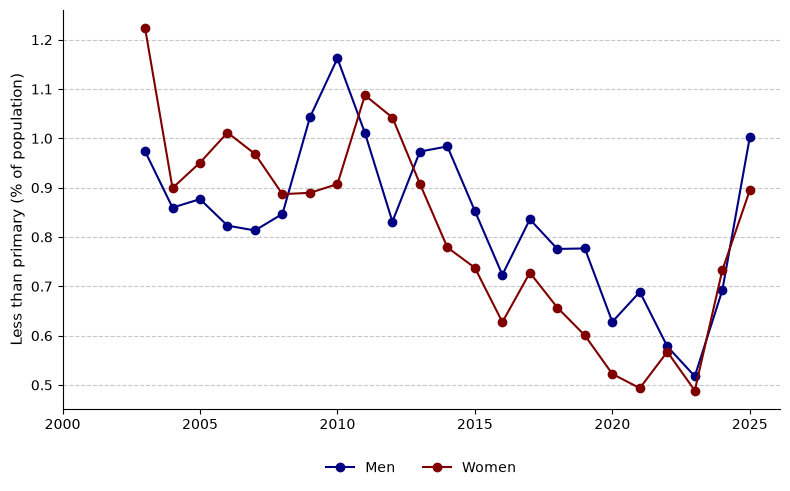

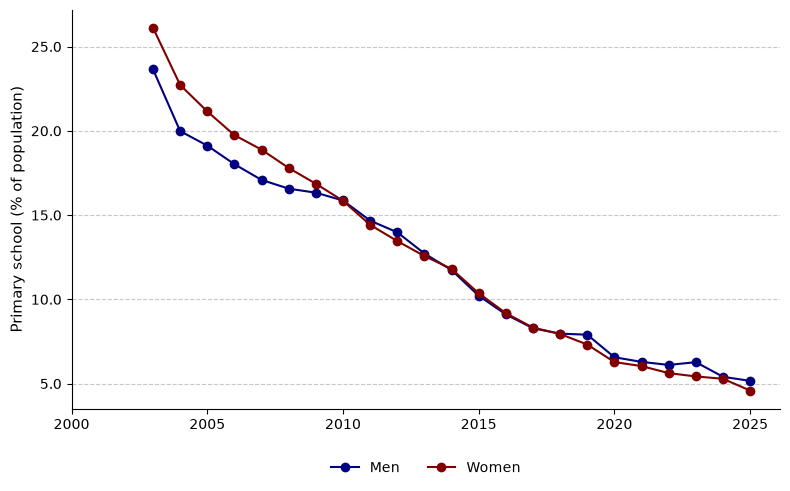

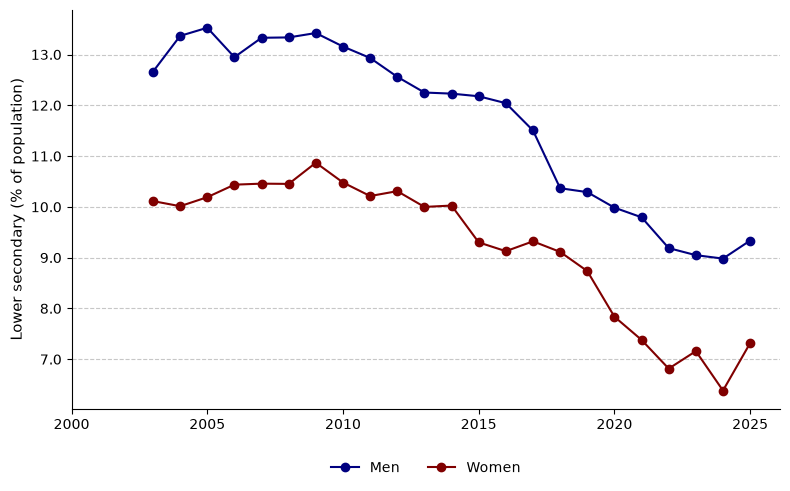

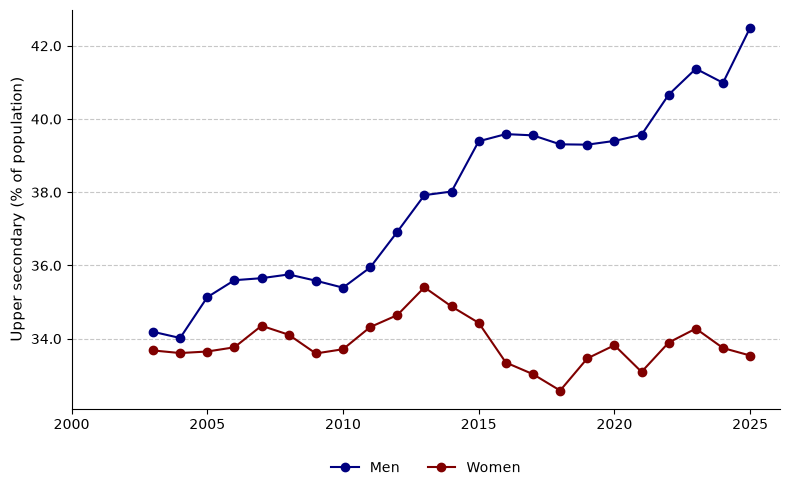

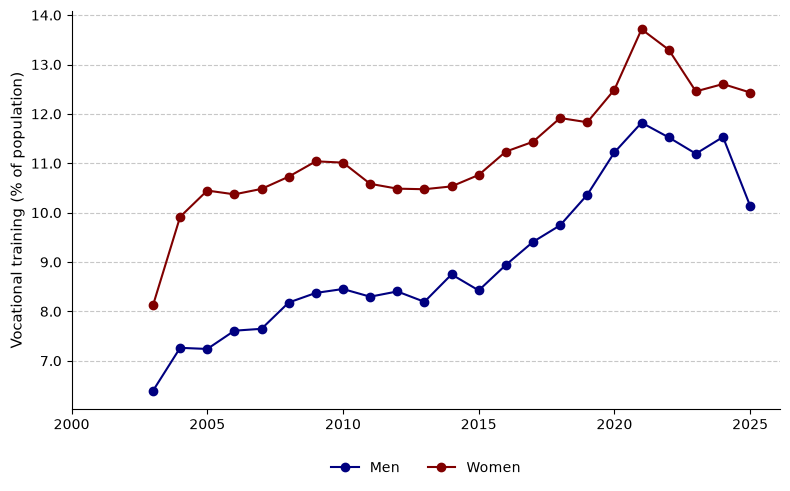

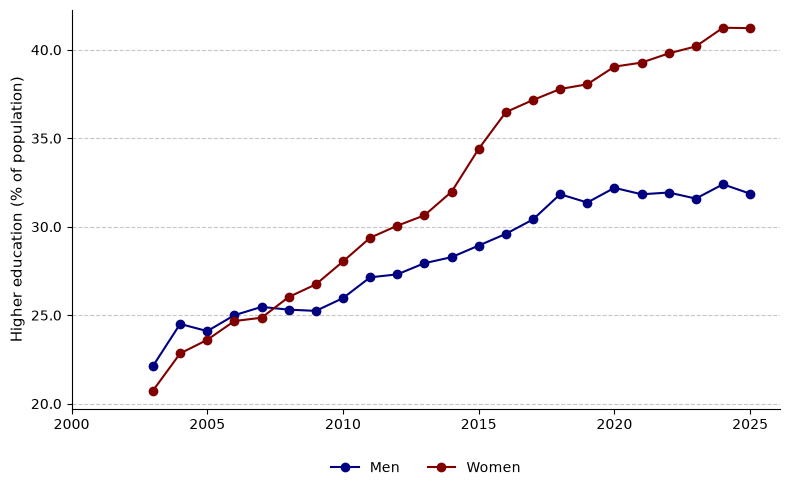

In [34]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results = "C:/Users/nikol/Desktop/Thesis_Data/"

# ==============================================================================
# 2003-2020 Quarterly Data Aggregation
# ==============================================================================
print("Loading quarterly dataset for 2003-2020 aggregation...")
df_q = pd.read_stata(os.path.join(results, "lfs_iza_2003_2025.dta"), convert_categoricals=False)

df_q_sub = df_q[
    (df_q['year'].between(2003, 2020)) & 
    (df_q['age'].between(25, 54)) & 
    (df_q['edulevel'].notna())
].copy()

print("Checking edulevel values in 2003-2020 data:")
print(df_q_sub['edulevel'].value_counts().sort_index())

for i in range(1, 7):
    df_q_sub[f'educ{i}'] = np.where(df_q_sub['edulevel'] == i, df_q_sub['weightq'], 0)

educ_cols = [f'educ{i}' for i in range(1, 7)]
collapse_sum_q = df_q_sub.groupby(['year', 'quarter', 'female'])[educ_cols].sum().reset_index()
collapse_mean_03_20 = collapse_sum_q.groupby(['year', 'female'])[educ_cols].mean().reset_index()
collapse_mean_03_20.to_stata(os.path.join(results, "edulevel_2003_2020_ann.dta"), write_index=False, version=118)
del df_q, df_q_sub, collapse_sum_q

# ==============================================================================
# 2021-2025 Annual Data Aggregation
# ==============================================================================
print("\nLoading annual dataset for 2021-2025 aggregation...")
df_a = pd.read_stata(os.path.join(results, "lfs_iza_2021_2025_ann.dta"), convert_categoricals=False)

df_a_sub = df_a[
    (df_a['year'].between(2021, 2025)) & 
    (df_a['age'].between(25, 54)) & 
    (df_a['edulevel'].notna())
].copy()

for i in range(1, 7):
    df_a_sub[f'educ{i}'] = np.where(df_a_sub['edulevel'] == i, df_a_sub['weighty'], 0)

collapse_sum_21_25 = df_a_sub.groupby(['year', 'female'])[educ_cols].sum().reset_index()
collapse_sum_21_25.to_stata(os.path.join(results, "edulevel_2021_2025_ann.dta"), write_index=False, version=118)
del df_a, df_a_sub

# ==============================================================================
# Append and Calculate Population & Shares
# ==============================================================================
print("\nAppending and calculating population shares...")
pooled_edu = pd.concat([collapse_mean_03_20, collapse_sum_21_25], ignore_index=True)
pooled_edu = pooled_edu.sort_values(by=['female', 'year']).reset_index(drop=True)

pooled_edu['pop'] = pooled_edu[educ_cols].sum(axis=1)

for col in educ_cols:
    pooled_edu[f'pct_{col}'] = 100 * (pooled_edu[col] / pooled_edu['pop'])

print(" Aggregation complete. Preview of the dataset:")
display(pooled_edu.head())

# ==============================================================================
# Generation of the 6 Graphs
# ==============================================================================
edu_titles = {
    1: "Less than primary (% of population)",
    2: "Primary school (% of population)",
    3: "Lower secondary (% of population)",
    4: "Upper secondary (% of population)",
    5: "Vocational training (% of population)",
    6: "Higher education (% of population)"
}

for i in range(1, 7):
    pct_col = f'pct_educ{i}'
    
    men = pooled_edu[pooled_edu['female'] == 0]
    women = pooled_edu[pooled_edu['female'] == 1]
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(men['year'], men[pct_col], marker='o', color='navy', label='Men', linestyle='-')
    plt.plot(women['year'], women[pct_col], marker='o', color='maroon', label='Women', linestyle='-')
    
    plt.ylabel(edu_titles[i], fontsize=11)
    plt.xlabel("") 
    plt.xticks([2000, 2005, 2010, 2015, 2020, 2025])
    
    plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

In [35]:
import os
import pandas as pd
import numpy as np

results = "C:/Users/nikol/Desktop/Thesis_Data/"

# ==============================================================================
# 2003-2020 Field of Study (Quarterly Data)
# ==============================================================================
print("Processing field of study for 2003-2020...")
df_q = pd.read_stata(os.path.join(results, "lfs_iza_2003_2025.dta"), convert_categoricals=False)

# Keep 2003-2020, age 25-54, Higher Education (6), and valid fields of study (1-8)
df_q_sub = df_q[(df_q['year'].between(2003, 2020)) & 
                (df_q['age'].between(25, 54)) & 
                (df_q['edulevel'] == 6) & 
                (df_q['fieldstudy_broad'].between(1, 8))].copy()

# Generate educ1 to educ8 based on fieldstudy_broad and weightq
for i in range(1, 9):
    df_q_sub[f'educ{i}'] = np.where(df_q_sub['fieldstudy_broad'] == i, df_q_sub['weightq'], 0)

educ_cols = [f'educ{i}' for i in range(1, 9)]

# Collapse (sum) by year, quarter, female
collapse_sum_q = df_q_sub.groupby(['year', 'quarter', 'female'])[educ_cols].sum().reset_index()

# Collapse (mean) by year, female to get the annual average
collapse_mean_03_20 = collapse_sum_q.groupby(['year', 'female'])[educ_cols].mean().reset_index()

# Save
collapse_mean_03_20.to_stata(os.path.join(results, "edufield_2003_2020_ann.dta"), write_index=False, version=118)

del df_q, df_q_sub, collapse_sum_q


# ==============================================================================
# 2021-2025 Field of Study (Annual Data)
# ==============================================================================
print("Processing field of study for 2021-2025...")
df_a = pd.read_stata(os.path.join(results, "lfs_iza_2021_2025_ann.dta"), convert_categoricals=False)

# Keep 2021-2025, age 25-54, Higher Education (6), and valid fields of study (1-8)
df_a_sub = df_a[(df_a['year'].between(2021, 2025)) & 
                (df_a['age'].between(25, 54)) & 
                (df_a['edulevel'] == 6) & 
                (df_a['fieldstudy_broad'].between(1, 8))].copy()

# Generate educ1 to educ8 based on fieldstudy_broad and weighty
for i in range(1, 9):
    df_a_sub[f'educ{i}'] = np.where(df_a_sub['fieldstudy_broad'] == i, df_a_sub['weighty'], 0)

# Collapse (sum) by year, female
collapse_sum_21_25 = df_a_sub.groupby(['year', 'female'])[educ_cols].sum().reset_index()

# Save
collapse_sum_21_25.to_stata(os.path.join(results, "edufield_2021_2025_ann.dta"), write_index=False, version=118)

del df_a, df_a_sub
print(" Field of study aggregation complete and saved to disk.")

Processing field of study for 2003-2020...


C:\Users\nikol\AppData\Local\Temp\ipykernel_8272\1482585414.py:11: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df_q = pd.read_stata(os.path.join(results, "lfs_iza_2003_2025.dta"), convert_categoricals=False)


Processing field of study for 2021-2025...
 Field of study aggregation complete and saved to disk.


Appending field of study datasets...
--- Graph 1: All Graduates ---


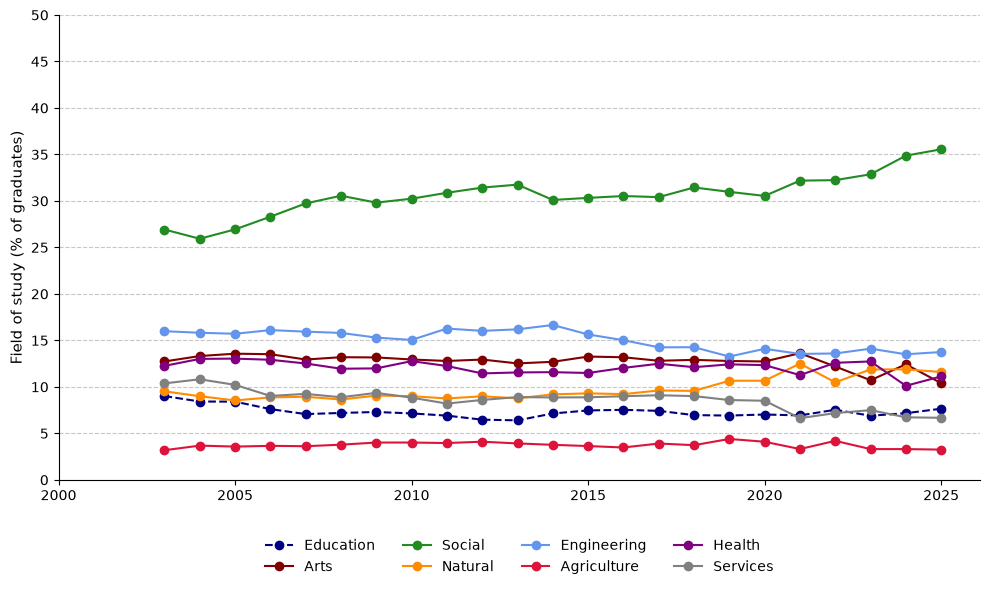

--- Graph 2: Male Graduates ---


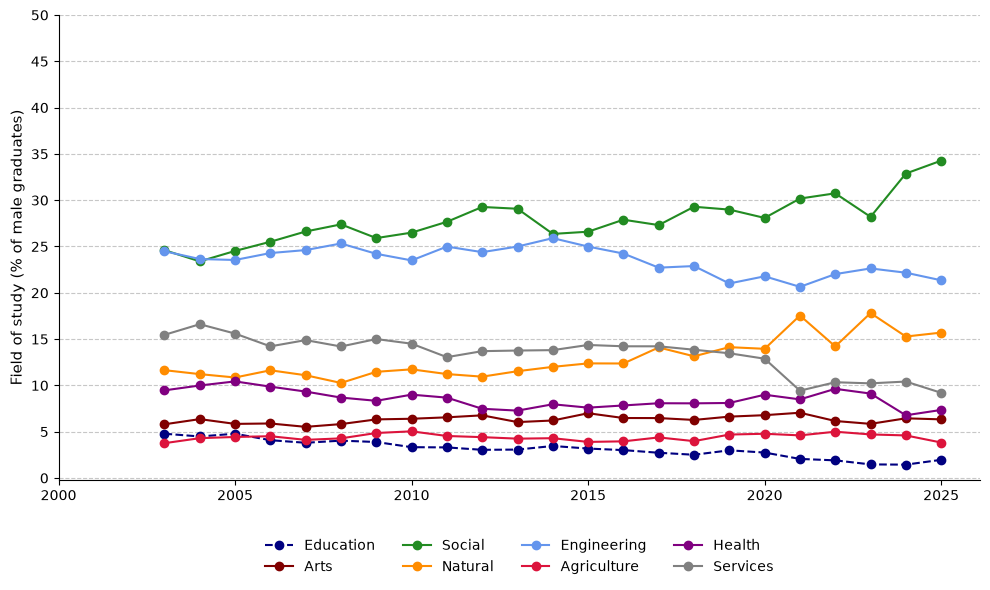

--- Graph 3: Female Graduates ---


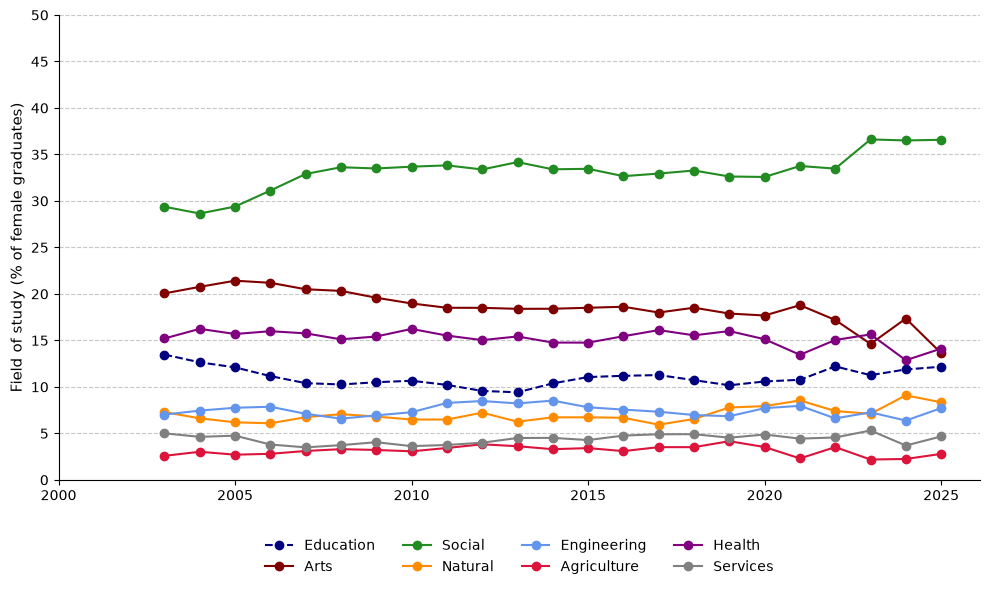

In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt

results = "C:/Users/nikol/Desktop/Thesis_Data/"

# ==============================================================================
# Load Data and Calculate Shares (Gender-Split)
# ==============================================================================
print("Appending field of study datasets...")
# Added convert_categoricals=False so female is loaded as 0 and 1
df_03_20 = pd.read_stata(os.path.join(results, "edufield_2003_2020_ann.dta"), convert_categoricals=False)
df_21_25 = pd.read_stata(os.path.join(results, "edufield_2021_2025_ann.dta"), convert_categoricals=False)

pooled_gender = pd.concat([df_03_20, df_21_25], ignore_index=True)
pooled_gender = pooled_gender.sort_values(by=['female', 'year']).reset_index(drop=True)

educ_cols = [f'educ{i}' for i in range(1, 9)]

# Calculate population and shares for Men/Women
pooled_gender['pop'] = pooled_gender[educ_cols].sum(axis=1)
for col in educ_cols:
    pooled_gender[f'pct_{col}'] = 100 * (pooled_gender[col] / pooled_gender['pop'])

# ==============================================================================
# Collapse for 'All' Graduates (Combined)
# ==============================================================================
pooled_all = pooled_gender.groupby('year')[educ_cols].sum().reset_index()

pooled_all['pop'] = pooled_all[educ_cols].sum(axis=1)
for col in educ_cols:
    pooled_all[f'pct_{col}'] = 100 * (pooled_all[col] / pooled_all['pop'])

# ==============================================================================
# Graphing Configuration & Generation
# ==============================================================================
plot_config = {
    'pct_educ1': {'label': 'Education',   'color': 'navy',           'linestyle': '--'},
    'pct_educ2': {'label': 'Arts',        'color': 'maroon',         'linestyle': '-'},
    'pct_educ3': {'label': 'Social',      'color': 'forestgreen',    'linestyle': '-'},
    'pct_educ4': {'label': 'Natural',     'color': 'darkorange',     'linestyle': '-'},
    'pct_educ5': {'label': 'Engineering', 'color': 'cornflowerblue', 'linestyle': '-'},
    'pct_educ6': {'label': 'Agriculture', 'color': 'crimson',        'linestyle': '-'},
    'pct_educ7': {'label': 'Health',      'color': 'purple',         'linestyle': '-'},
    'pct_educ8': {'label': 'Services',    'color': 'gray',           'linestyle': '-'} 
}

def plot_field_shares(df, y_title):
    plt.figure(figsize=(10, 6))
    
    for col, config in plot_config.items():
        plt.plot(df['year'], df[col], marker='o', 
                 color=config['color'], linestyle=config['linestyle'], 
                 label=config['label'])
    
    plt.yticks(range(0, 55, 5))
    plt.xticks([2000, 2005, 2010, 2015, 2020, 2025])
    plt.ylabel(y_title, fontsize=11)
    plt.xlabel("") 
    
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print("--- Graph 1: All Graduates ---")
plot_field_shares(pooled_all, "Field of study (% of graduates)")

print("--- Graph 2: Male Graduates ---")
plot_field_shares(pooled_gender[pooled_gender['female'] == 0], "Field of study (% of male graduates)")

print("--- Graph 3: Female Graduates ---")
plot_field_shares(pooled_gender[pooled_gender['female'] == 1], "Field of study (% of female graduates)")

In [37]:
# ==============================================================================
# CREATION OF MASTER ANALYSIS DATASET & EDU_FIELD RECODING
# ==============================================================================
import os
import pandas as pd
import numpy as np
import gc

results = "C:/Users/nikol/Desktop/Thesis_Data/"

print("Loading and appending datasets for Master file creation...")

# Load the component parts from disk sequentially to save memory
master_files = [
    "lfs_iza_2003_2005.dta",
    "lfs_iza_2006_2007.dta",
    "lfs_iza_2008_2020.dta",
    "lfs_iza_2021_2025_ann.dta"
]

master_frames = []
for f in master_files:
    f_path = os.path.join(results, f)
    if os.path.exists(f_path):
        print(f"Loading {f}...")
        # convert_categoricals=False ensures strict numeric alignment
        master_frames.append(pd.read_stata(f_path, convert_categoricals=False))

df_master = pd.concat(master_frames, ignore_index=True)
del master_frames
gc.collect()

# Sort data cleanly
df_master = df_master.sort_values(by=['year', 'quarter']).reset_index(drop=True)
df_master.columns = df_master.columns.str.replace('$', '_', regex=False)

print("Creating unified 'edu_field' variable...")
# Initialize edu_field with NaN
df_master['edu_field'] = np.nan

# Map general education levels (10, 20, 30, 40, 50)
df_master.loc[df_master['edulevel'] == 1, 'edu_field'] = 10
df_master.loc[df_master['edulevel'] == 2, 'edu_field'] = 20
df_master.loc[df_master['edulevel'] == 3, 'edu_field'] = 30
df_master.loc[df_master['edulevel'] == 4, 'edu_field'] = 40
df_master.loc[df_master['edulevel'] == 5, 'edu_field'] = 50

# Map higher education fields of study (61 - 68)
field_mapping = {
    1: 61, # Education
    2: 62, # Arts/Humanities
    3: 63, # Social Sci/Law
    4: 64, # Natural Sci/Math
    5: 65, # Engineering
    6: 66, # Agriculture
    7: 67, # Health
    8: 68  # Services
}

for field_code, new_code in field_mapping.items():
    df_master.loc[(df_master['edulevel'] == 6) & (df_master['fieldstudy_broad'] == field_code), 'edu_field'] = new_code

print("Creating unified 'final_weight' variable...")
# Use weighty for 2021+, weightq for earlier years
if 'weighty' in df_master.columns and 'weightq' in df_master.columns:
    df_master['final_weight'] = np.where(df_master['year'] >= 2021, df_master['weighty'], df_master['weightq'])
elif 'weightq' in df_master.columns:
    df_master['final_weight'] = df_master['weightq']

master_save_path = os.path.join(results, "lfs_iza_2003_2025_MASTER.dta")
print(f"Saving master dataset to {master_save_path} (this may take a moment)...")
df_master.to_stata(master_save_path, write_index=False, version=118)

print(f" Master dataset created and saved successfully. Total rows: {df_master.shape[0]}")

Loading and appending datasets for Master file creation...
Loading lfs_iza_2003_2005.dta...


C:\Users\nikol\AppData\Local\Temp\ipykernel_8272\1244127184.py:27: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  master_frames.append(pd.read_stata(f_path, convert_categoricals=False))


Loading lfs_iza_2006_2007.dta...
Loading lfs_iza_2008_2020.dta...
Loading lfs_iza_2021_2025_ann.dta...
Creating unified 'edu_field' variable...
Creating unified 'final_weight' variable...
Saving master dataset to C:/Users/nikol/Desktop/Thesis_Data/lfs_iza_2003_2025_MASTER.dta (this may take a moment)...
 Master dataset created and saved successfully. Total rows: 5721082


In [38]:
# ==============================================================================
# LABOUR MARKET OUTCOMES AND SAMPLE SELECTION
# ==============================================================================
import os
import pandas as pd
import numpy as np

results = "C:/Users/nikol/Desktop/Thesis_Data/"

print("Loading master dataset for labor market analysis...")
df = pd.read_stata(os.path.join(results, "lfs_iza_2003_2025_MASTER.dta"), convert_categoricals=False)

# Apply sample selection criteria: 2003-2025, age 25-54, non-missing edu_field and econact
print("Applying sample selection filters...")
sub_mask = (
    df['year'].between(2003, 2025) & 
    df['age'].between(25, 54) & 
    df['edu_field'].notna() & 
    df['econact'].notna()
)
df_analysis = df[sub_mask].copy()

# 1. Labor Force Participation (inlf)
# econact: 1 = employed, 2 = unemployed, 3 = inactive
df_analysis['inlf'] = np.select(
    [df_analysis['econact'].isin([1, 2]), df_analysis['econact'] == 3], 
    [1, 0], 
    default=np.nan
)

# 2. Employment (empl)
df_analysis['empl'] = np.select(
    [df_analysis['econact'] == 1, df_analysis['econact'].isin([2, 3])], 
    [1, 0], 
    default=np.nan
)

# 3. Unemployment (unem) - conditional on being in the labor force (econact 1 or 2)
df_analysis['unem'] = np.select(
    [df_analysis['econact'] == 1, df_analysis['econact'] == 2], 
    [0, 1], 
    default=np.nan
)

# 4. Usual Working Hours per week (hours) - replacing missing with 0
df_analysis['hours'] = df_analysis['uhours'].fillna(0)

# 5. Wage Earner (wageearner)
df_analysis['wageearner'] = np.select(
    [df_analysis['jposition'] == 2, df_analysis['jposition'].isin([1, 3])], 
    [1, 0], 
    default=np.nan
)

# 6. Full-Time Status (fulltime) - 35+ hours is full-time
df_analysis['fulltime'] = np.select(
    [df_analysis['uhours'] >= 35, (df_analysis['uhours'] > 0) & (df_analysis['uhours'] < 35)], 
    [1, 0], 
    default=np.nan
)

print(f" Labor market variables generated successfully. Final analysis sample size: {df_analysis.shape[0]:,} rows")

Loading master dataset for labor market analysis...
Applying sample selection filters...
 Labor market variables generated successfully. Final analysis sample size: 2,074,587 rows


In [40]:
# ==============================================================================
# CPI DEFLATION, REAL MONTHLY EARNINGS & SUMMARY STATISTICS 
# ==============================================================================
import pandas as pd
import numpy as np

# CPI Mapping Dictionary (Base 2020 = 100)
cpi_dict = {
    2003: 79.538462413175,
    2004: 81.8441615155874,
    2005: 84.7455968277131,
    2006: 87.4540203145572,
    2007: 89.985815094533,
    2008: 93.7227427475713,
    2009: 94.8568572431481,
    2010: 99.3274434515502,
    2011: 102.634918371517,
    2012: 104.176001981024,
    2013: 103.216257739865,
    2014: 101.861810221648,
    2015: 100.093588643971,
    2016: 99.2671583486554,
    2017: 100.380200303234,
    2018: 101.008199438129,
    2019: 101.26374285772,
    2020: 100.0,
    2021: 101.223825627838,
    2022: 110.987127938493,
    2023: 114.832611579267,
    2024: 117.980743502376,
    2025: 120.908577872821
}

# Map CPI and calculate real monthly earnings
df_analysis['cpi'] = df_analysis['year'].map(cpi_dict)
df_analysis['salary_cont_real'] = df_analysis['salary_cont'] / (df_analysis['cpi'] / 100)

# Log monthly earnings (lwn = nominal, lwr = real)
df_analysis['lwn'] = np.log(df_analysis['salary_cont'])
df_analysis['lwr'] = np.log(df_analysis['salary_cont_real'])

# Monthly Wage Inequality Indicators (Adjusted for Stata percentile matching)
df_analysis['p20_sal'] = df_analysis.groupby(['year', 'female'])['salary_cont_real'].transform(
    lambda x: x.quantile(0.20, interpolation='nearest')
)
df_analysis['p80_sal'] = df_analysis.groupby(['year', 'female'])['salary_cont_real'].transform(
    lambda x: x.quantile(0.80, interpolation='nearest')
)

df_analysis['ineq20'] = df_analysis['salary_cont_real'] / df_analysis['p20_sal']
df_analysis['ineq20D'] = np.where(df_analysis['ineq20'] < 1, 1, 0)
df_analysis.loc[df_analysis['ineq20'].isna() | df_analysis['p20_sal'].isna(), 'ineq20D'] = np.nan

df_analysis['ineq80'] = df_analysis['salary_cont_real'] / df_analysis['p80_sal']
df_analysis['ineq80D'] = np.where(df_analysis['ineq80'] > 1, 1, 0)
df_analysis.loc[df_analysis['ineq80'].isna() | df_analysis['p80_sal'].isna(), 'ineq80D'] = np.nan


# Summary Statistics Tables (Weighted)
def weighted_mean(values, weights):
    valid = values.notna() & weights.notna()
    if valid.sum() == 0:
        return np.nan
    return np.average(values[valid], weights=weights[valid])

print("--- Education Field by Gender (%) ---")
edu_gender_w = df_analysis.groupby(['edu_field', 'female'])['final_weight'].sum().unstack(fill_value=0)
display((edu_gender_w.div(edu_gender_w.sum(axis=0), axis=1) * 100).round(2))

print("\n--- Gender Distribution (%) ---")
gender_counts = df_analysis.groupby('female')['final_weight'].sum()
display(((gender_counts / gender_counts.sum()) * 100).round(2))

print("\n--- Mean Age by Gender ---")
display(df_analysis.groupby('female').apply(lambda x: weighted_mean(x['age'], x['final_weight'])).round(2))

print("\n--- Economic Activity by Gender (%) ---")
econ_w = df_analysis.groupby(['econact', 'female'])['final_weight'].sum().unstack(fill_value=0)
display((econ_w.div(econ_w.sum(axis=0), axis=1) * 100).round(2))

print("\n--- Mean Working Hours by Gender ---")
display(df_analysis.groupby('female').apply(lambda x: weighted_mean(x['hours'], x['final_weight'])).round(2))

if 'nuts2' in df_analysis.columns:
    print("\n--- Regional Distribution (NUTS2) by Gender (%) ---")
    nuts_w = df_analysis.groupby(['nuts2', 'female'])['final_weight'].sum().unstack(fill_value=0)
    display((nuts_w.div(nuts_w.sum(axis=0), axis=1) * 100).round(2))


# Tabstat Equivalent 
print("\n--- Tabstat: Wage & Labor Market Statistics (salary_cont_real > 0) ---")
wage_sub = df_analysis[(df_analysis['salary_cont_real'] > 0) | (df_analysis['salary_cont_real'].isna())].copy()
tabstat_vars = ['lwr', 'salary_cont_real', 'uhours', 'age', 'female', 'fulltime']

tabstat_results = {}
for var in tabstat_vars:
    if var in wage_sub.columns:
        sub_v = wage_sub[[var, 'final_weight']].dropna()
        sub_v = sub_v[sub_v['final_weight'] > 0]
        vals = sub_v[var].to_numpy(dtype=float)
        wts = sub_v['final_weight'].to_numpy(dtype=float)
        
        # Weighted Mean & SD
        mean_val = np.average(vals, weights=wts)
        variance = np.average((vals - mean_val)**2, weights=wts) * (len(vals) / (len(vals) - 1))
        sd_val = np.sqrt(variance)
        
        # Weighted Median (p50) to match Stata
        sort_idx = np.argsort(vals, kind='mergesort')
        vals_sorted = vals[sort_idx]
        wts_sorted = wts[sort_idx]
        cum_wts = np.cumsum(wts_sorted)
        cutoff = 0.5 * cum_wts[-1]
        idx = np.searchsorted(cum_wts, cutoff, side='left')
        if np.isclose(cum_wts[idx], cutoff) and idx + 1 < len(vals):
            p50_val = (vals_sorted[idx] + vals_sorted[idx + 1]) / 2.0
        else:
            p50_val = vals_sorted[idx]
        
        tabstat_results[var] = {
            'Mean': mean_val,
            'SD': sd_val,
            'p50 (Median)': p50_val,
            'Min': vals.min(),
            'Max': vals.max()
        }

display(pd.DataFrame(tabstat_results).T.round(4))
print(" Step with monthly earnings successfully executed.")

C:\Users\nikol\New folder\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


--- Education Field by Gender (%) ---


female,0.0,1.0
edu_field,,
10.0,0.880000,0.870000
20.0,13.760000,14.410000
30.0,12.400000,9.900000
40.0,37.830002,34.599998
50.0,8.770000,11.090000
61.0,0.910000,3.150000
62.0,1.660000,5.540000
63.0,7.140000,9.520000
64.0,3.190000,1.980000



--- Gender Distribution (%) ---


female
0.0    50.049999
1.0    49.950001
Name: final_weight, dtype: float32

...


--- Regional Distribution (NUTS2) by Gender (%) ---


female,0.0,1.0
nuts2,,
1.0,5.320000,5.180000
2.0,16.920000,17.230000
3.0,2.490000,2.430000
4.0,2.920000,2.790000
5.0,6.360000,6.310000
6.0,1.840000,1.840000
7.0,6.140000,5.820000
8.0,5.180000,4.730000
9.0,37.299999,38.259998



--- Tabstat: Wage & Labor Market Statistics (salary_cont_real > 0) ---


,Mean,SD,p50 (Median),Min,Max
lwr,6.8347,0.4026,6.8809,2.1847,9.1123
salary_cont_real,1003.4104,393.4353,973.4868,8.8877,9066.4427
uhours,42.1990,11.5748,40.0000,0.0000,99.0000
age,39.7108,8.4778,40.0000,25.0000,54.0000
female,0.4995,0.5000,0.0000,0.0000,1.0000
fulltime,0.8650,0.3417,1.0000,0.0000,1.0000


 Step with monthly earnings successfully executed.


Generating all visualization charts using monthly earnings...


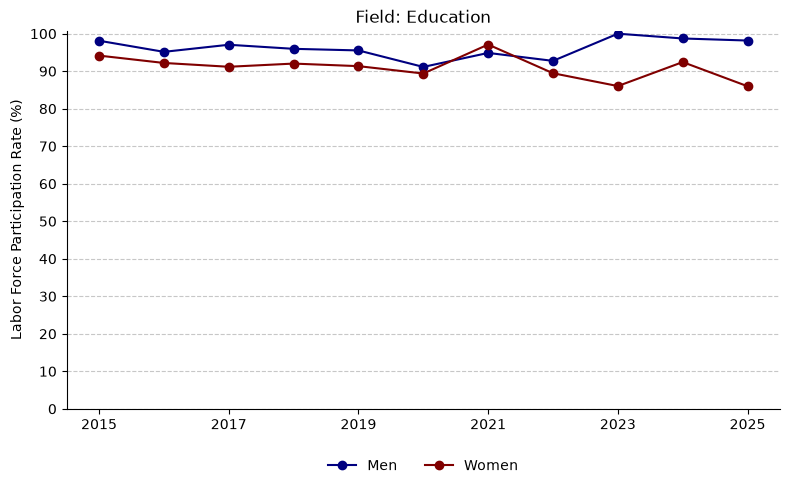

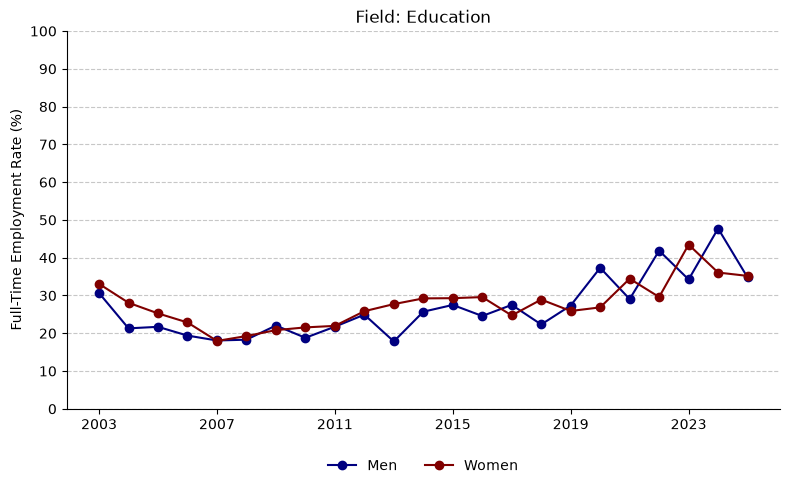

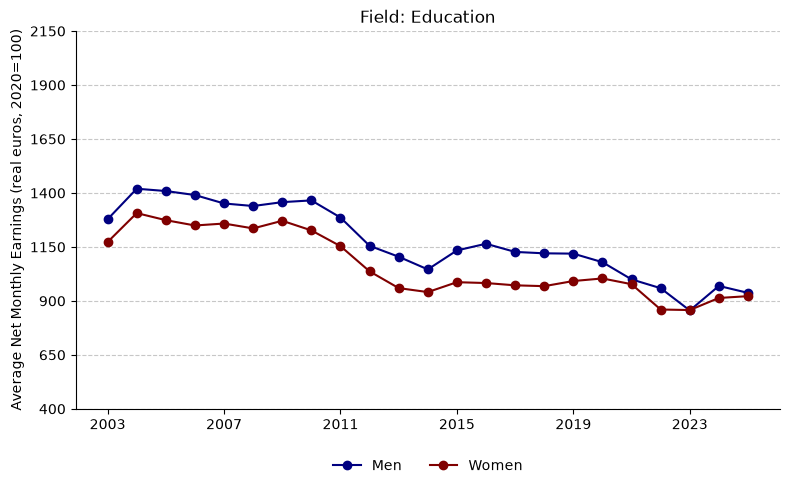

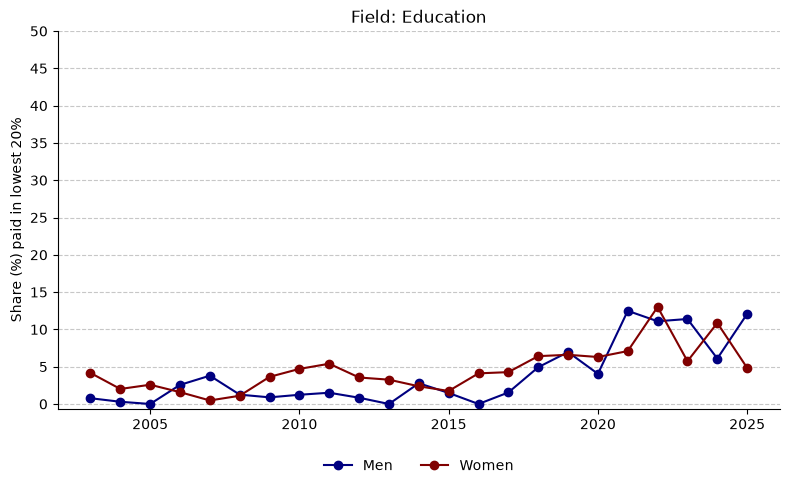

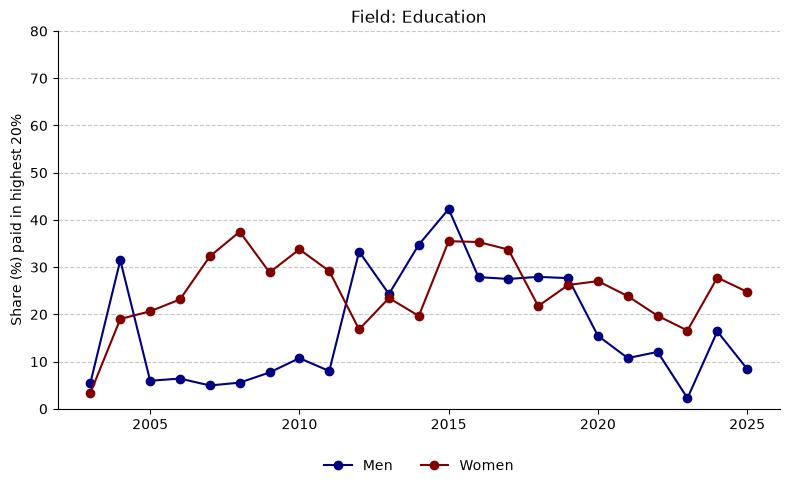

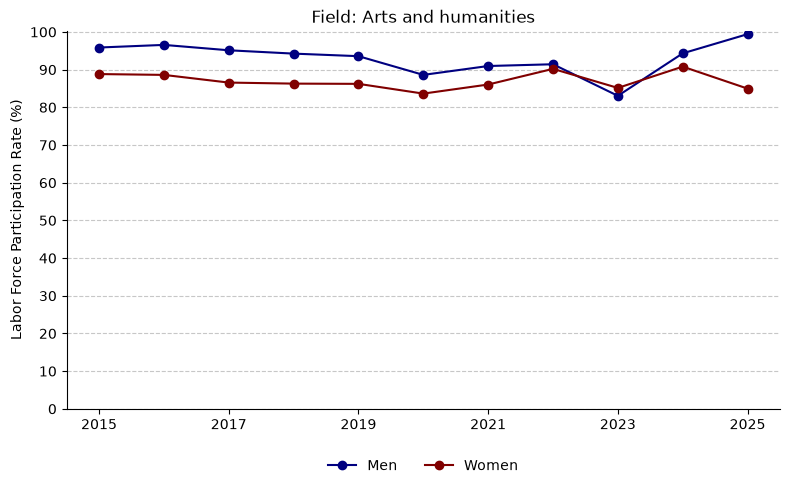

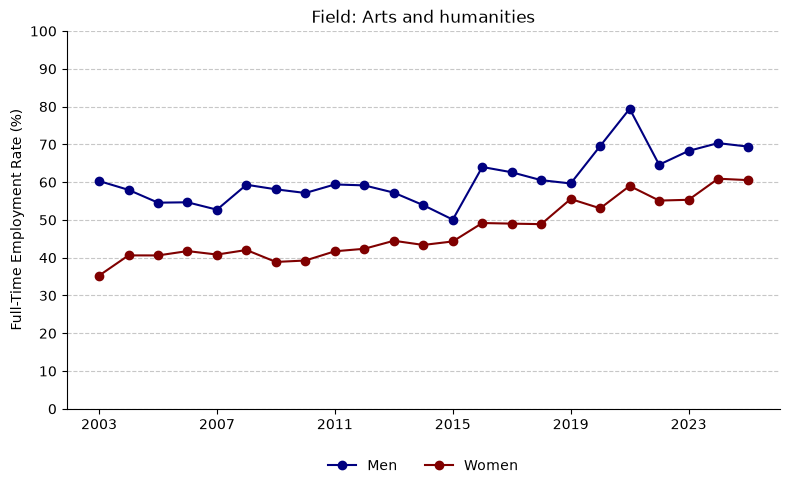

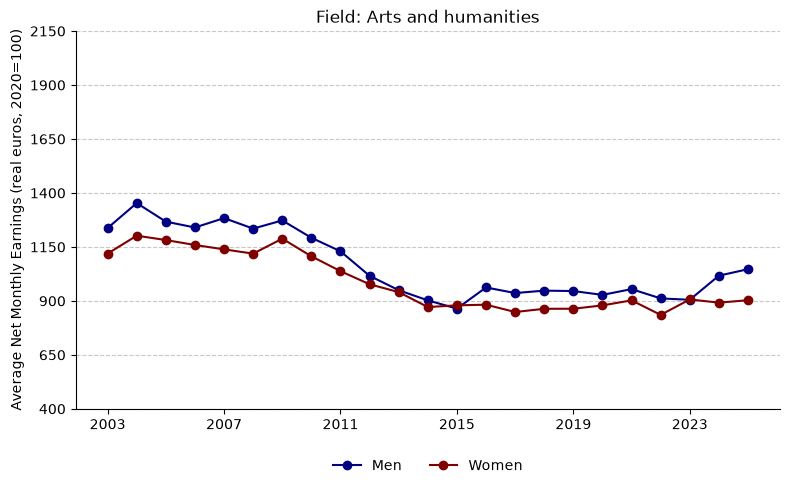

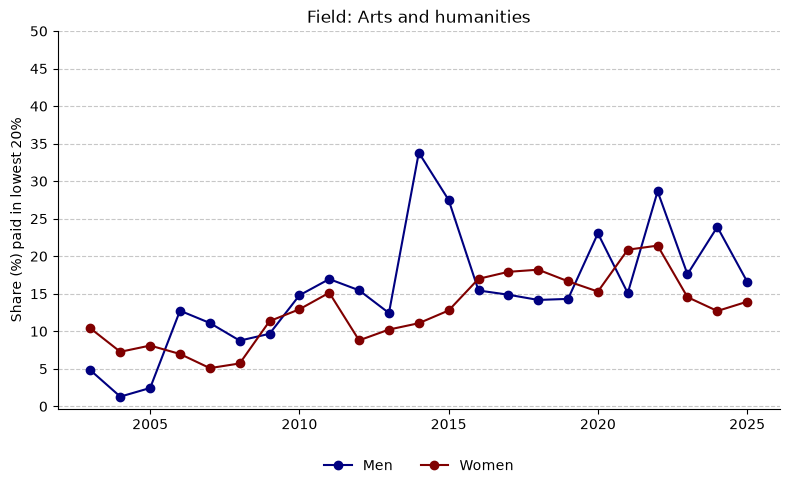

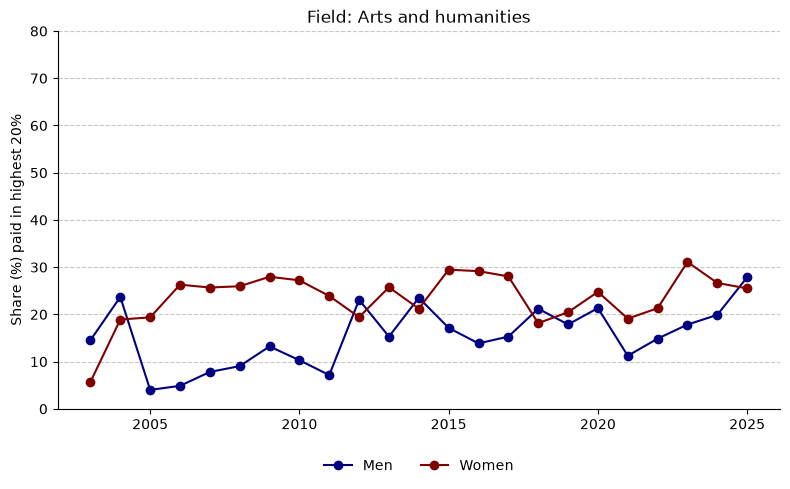

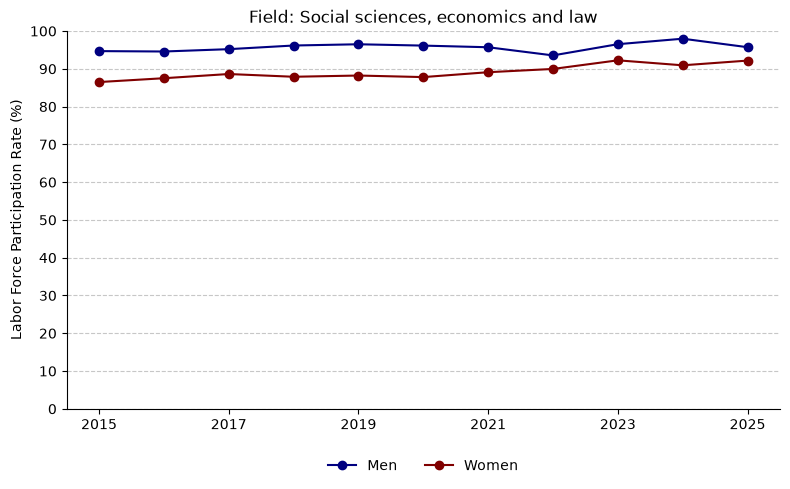

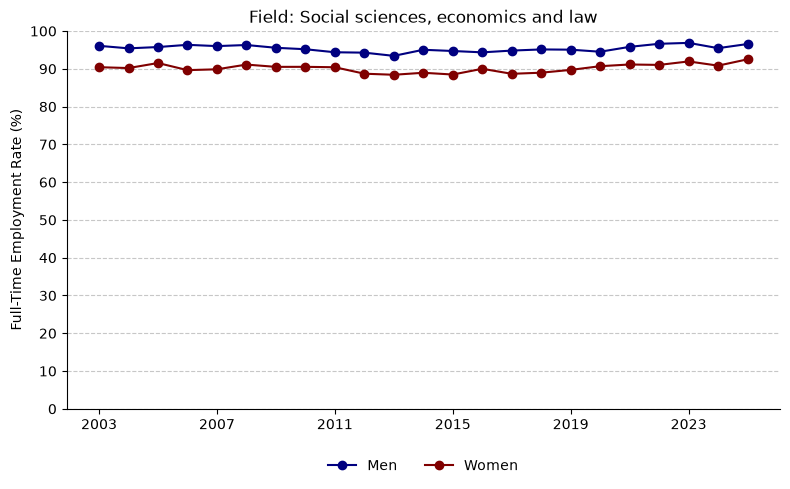

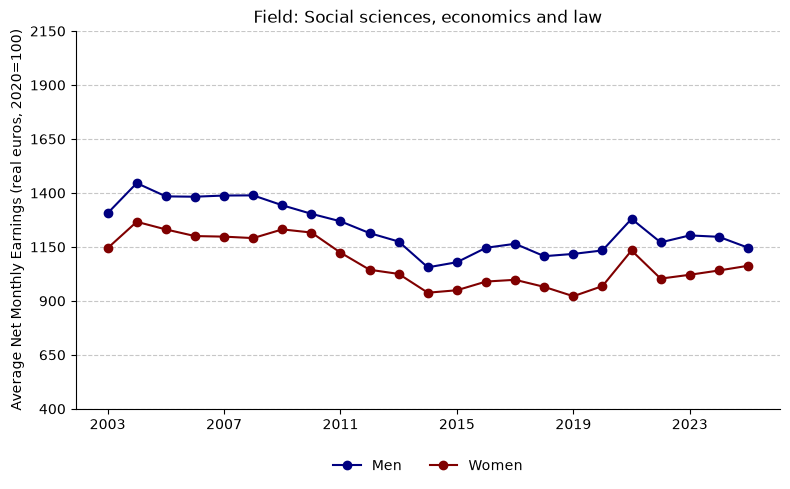

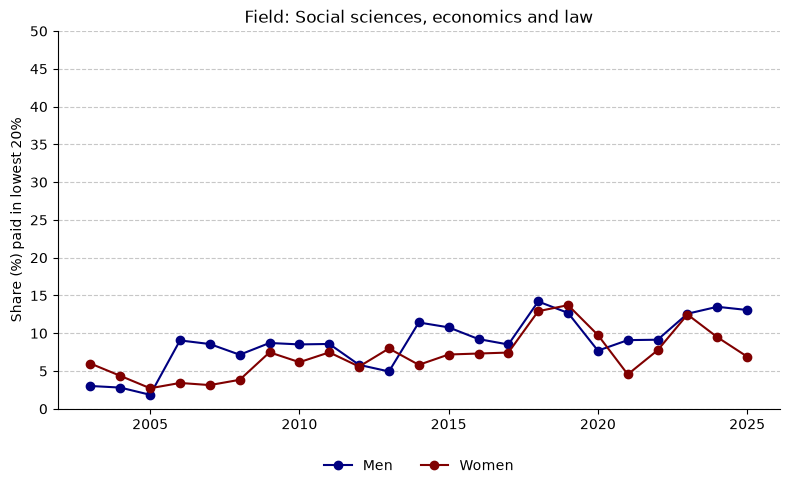

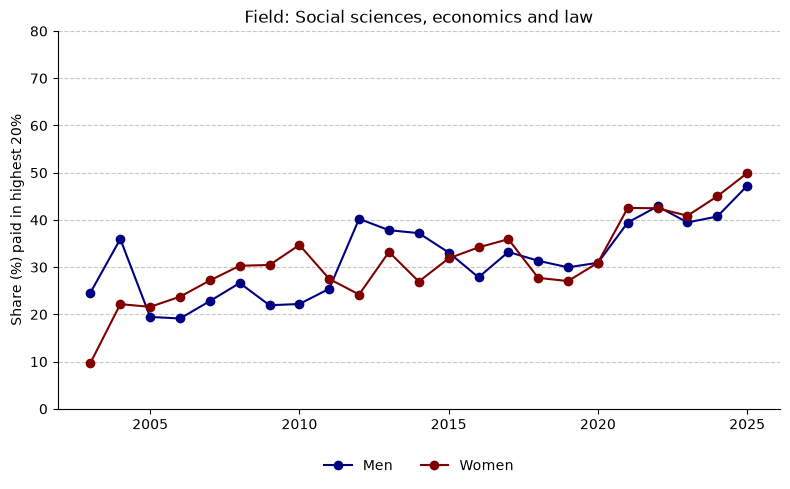

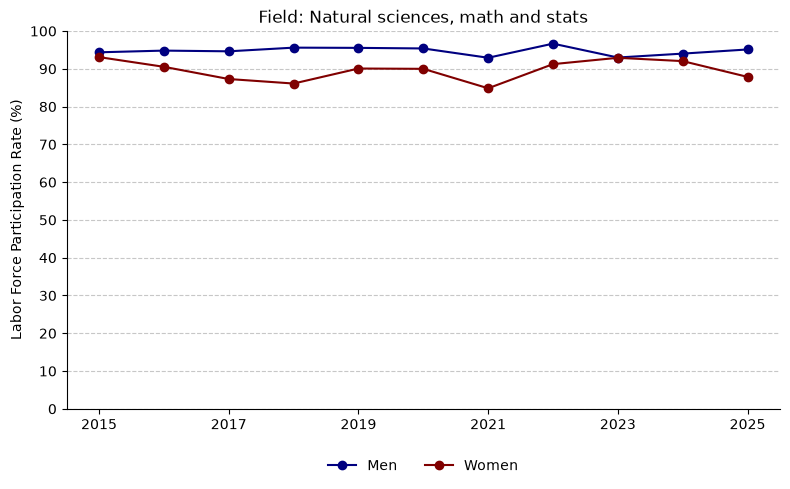

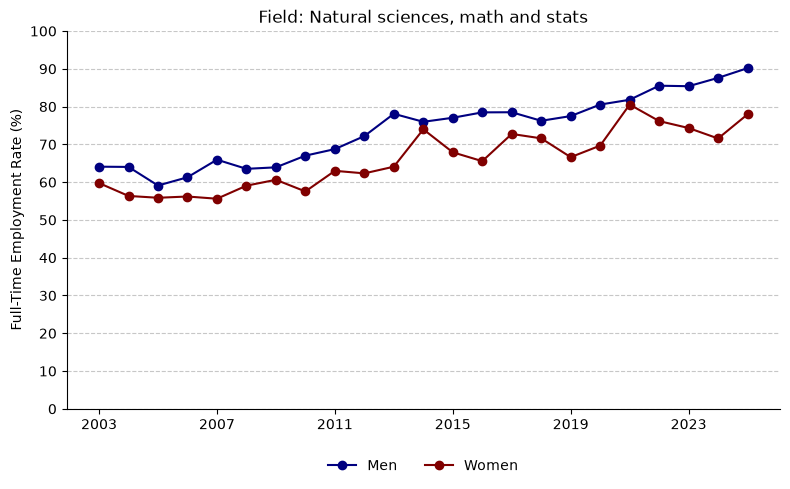

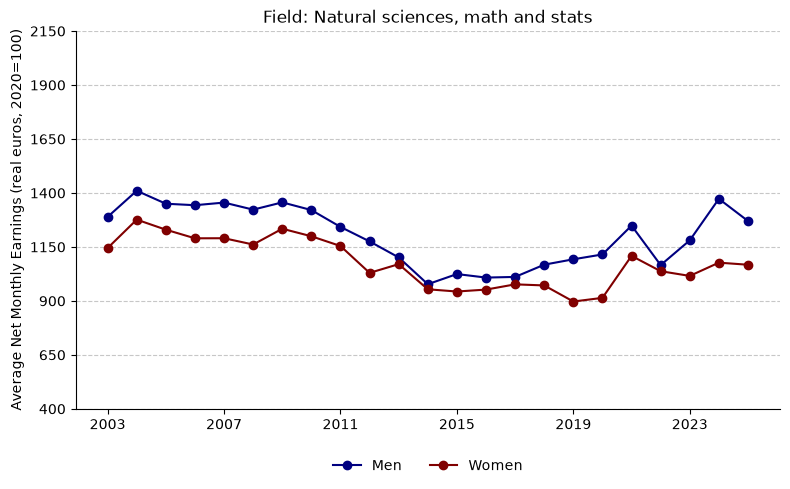

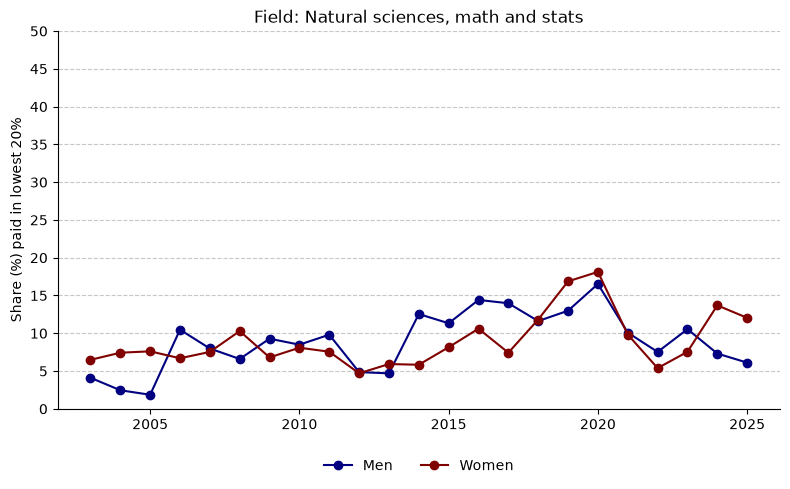

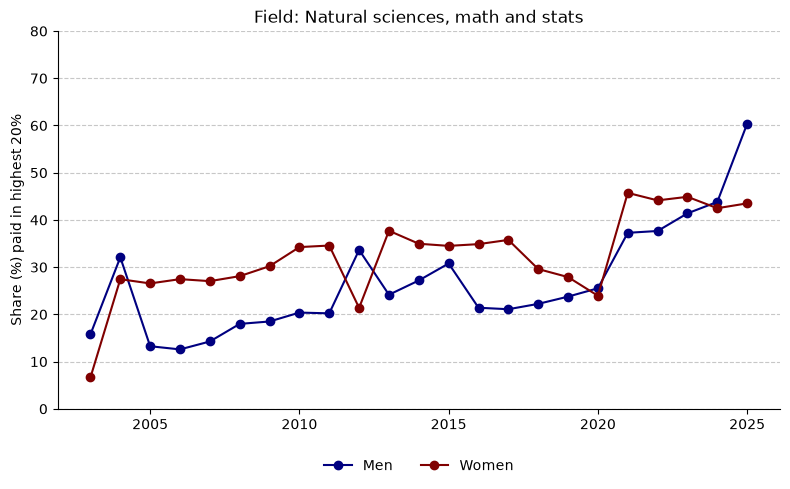

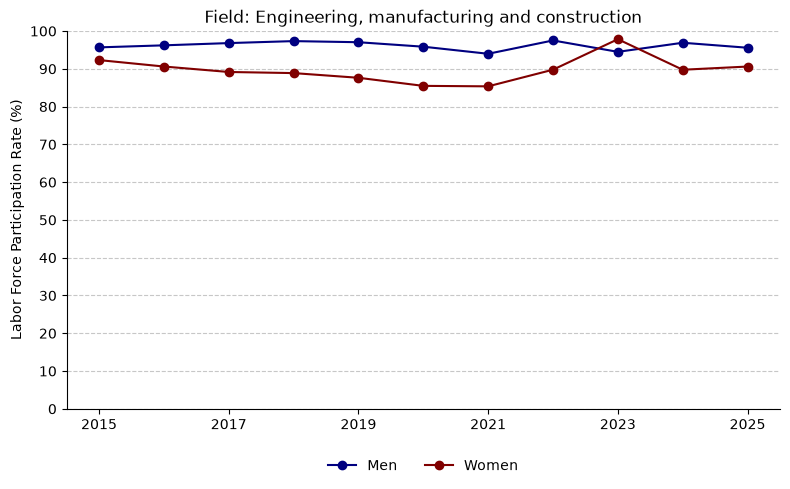

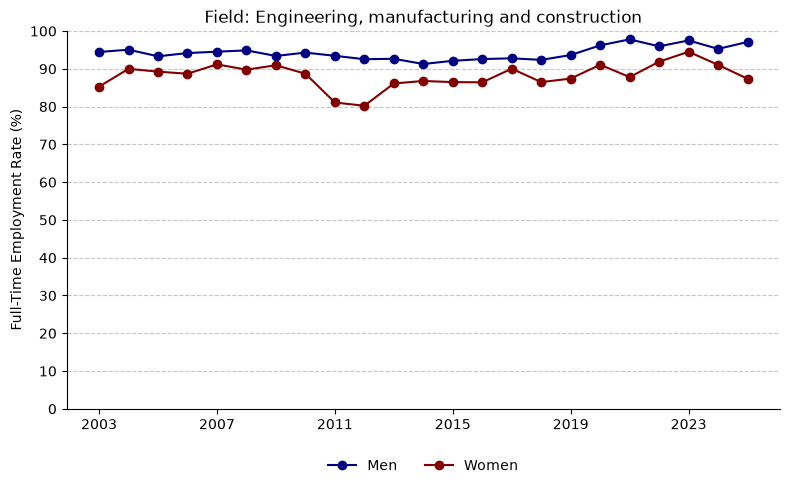

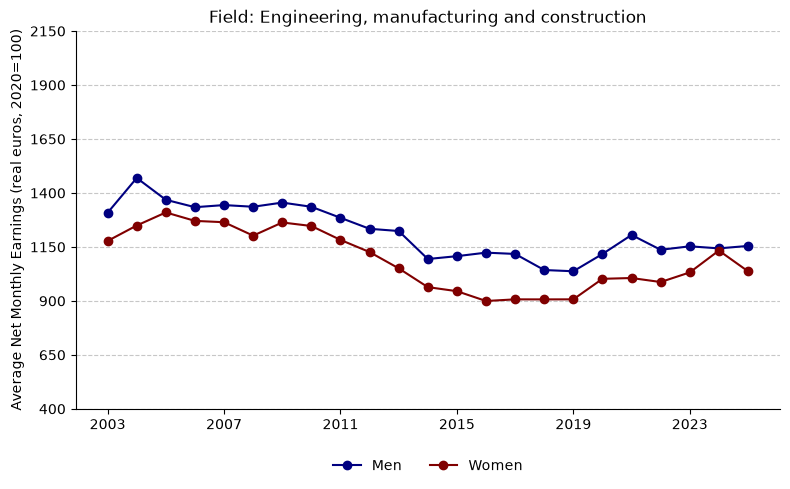

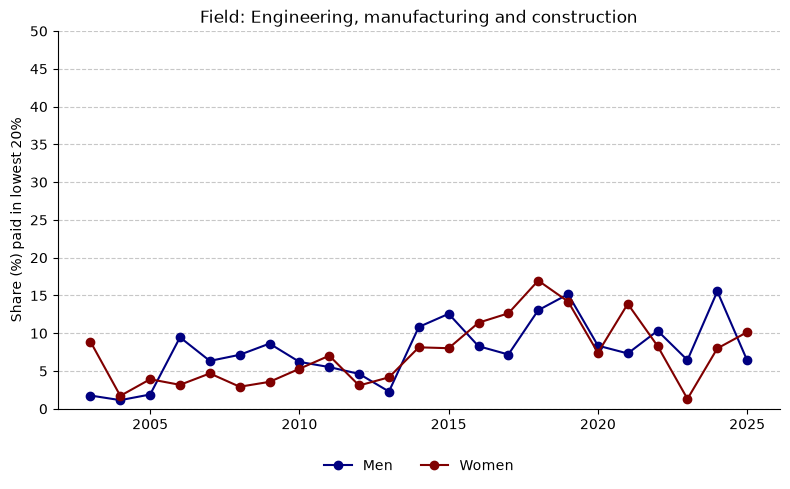

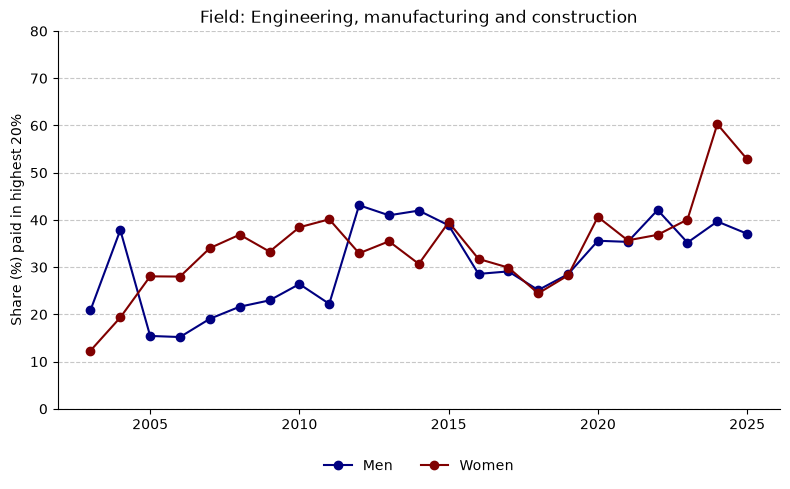

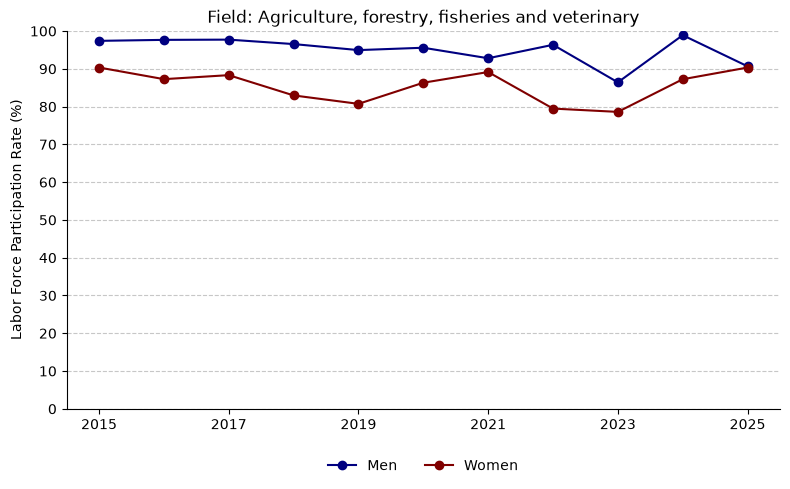

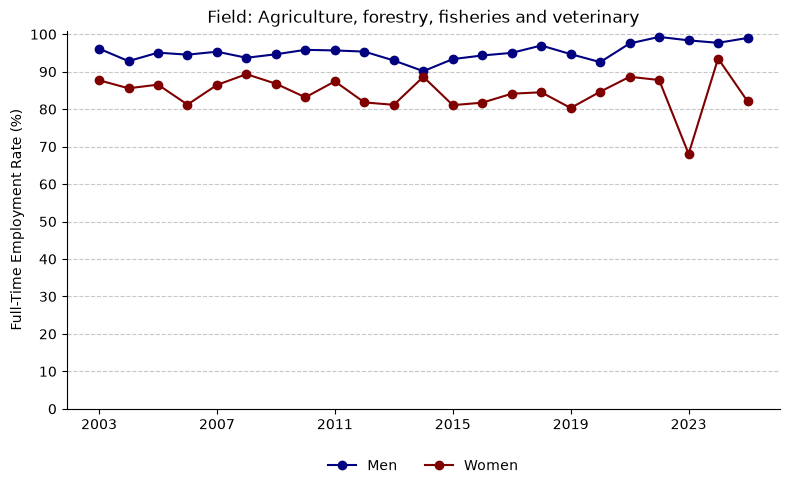

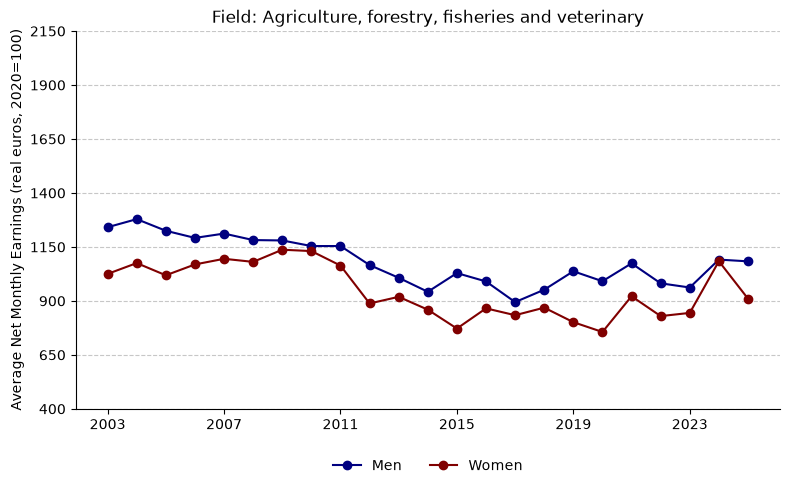

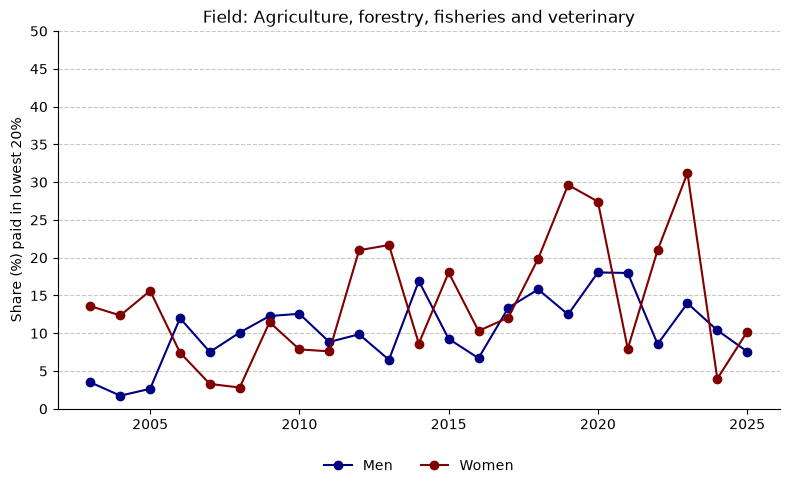

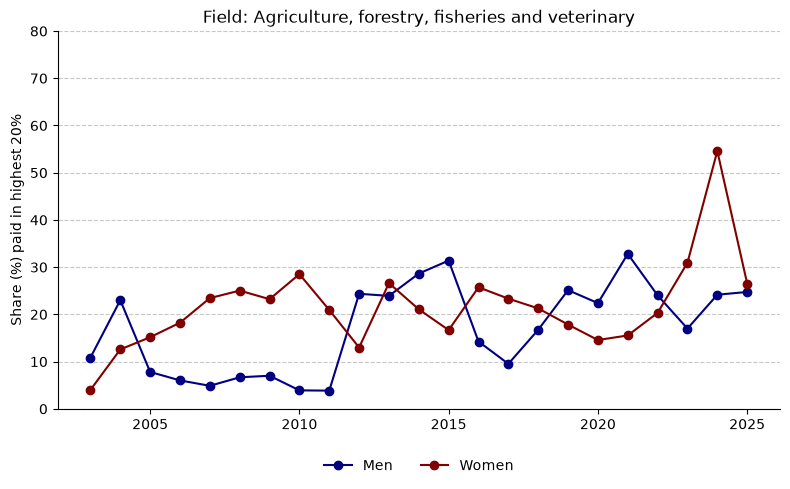

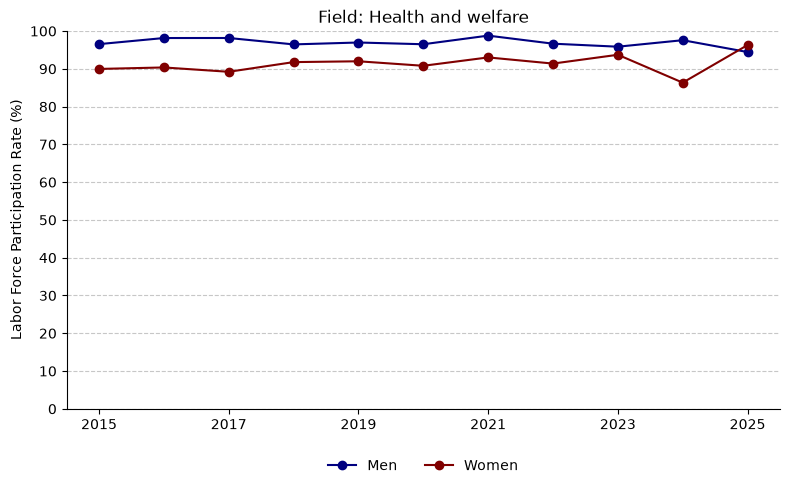

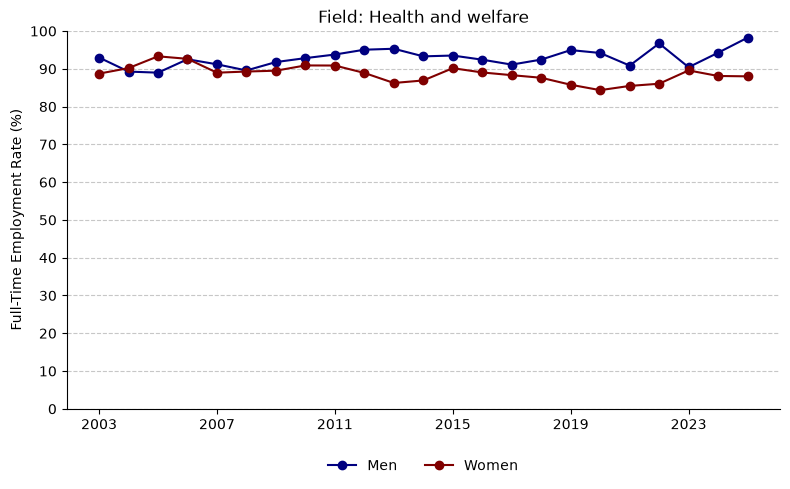

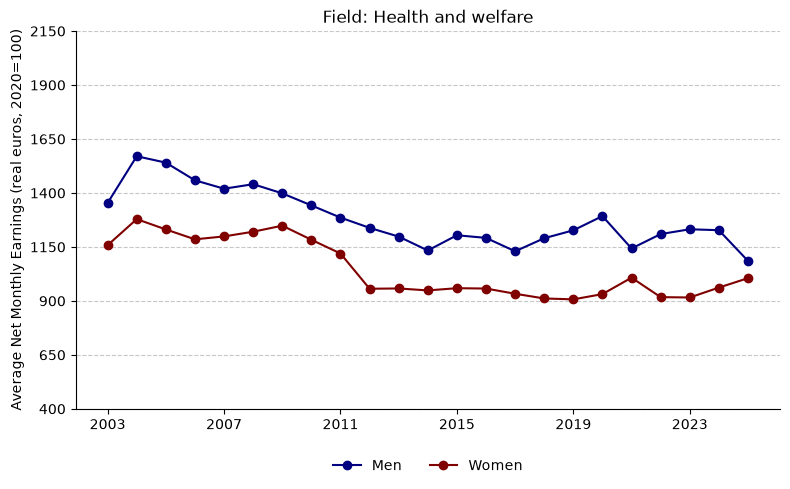

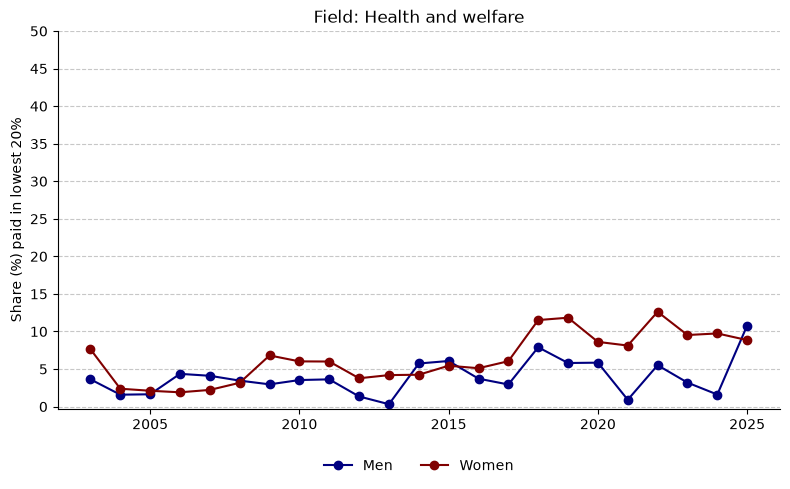

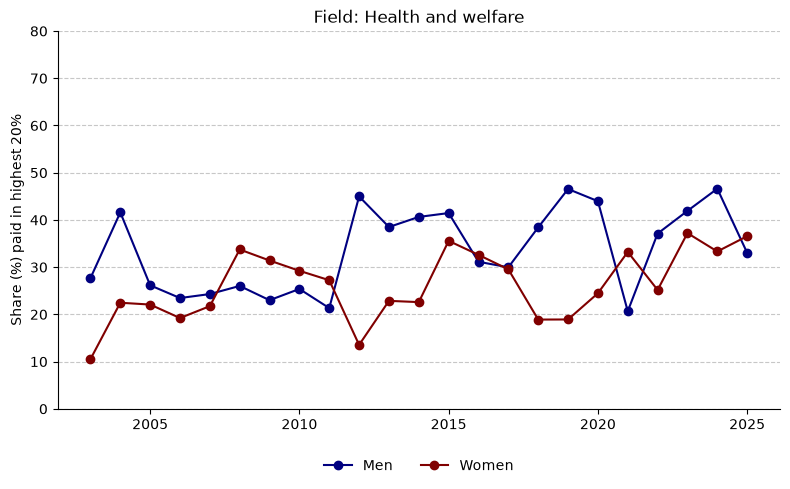

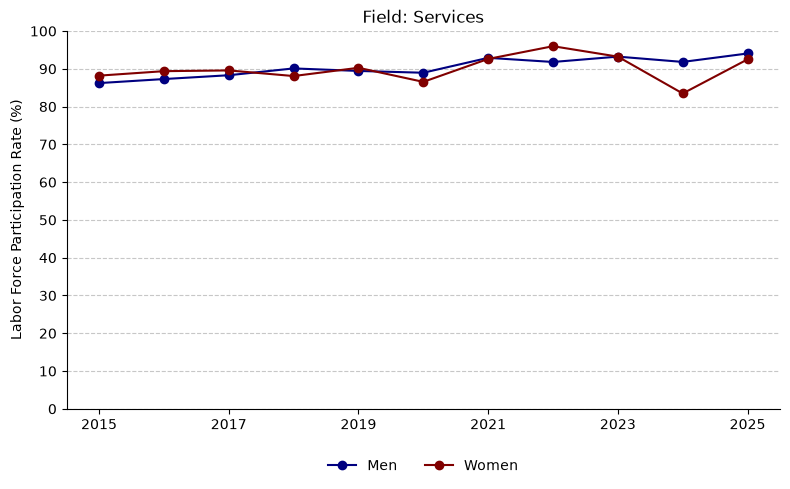

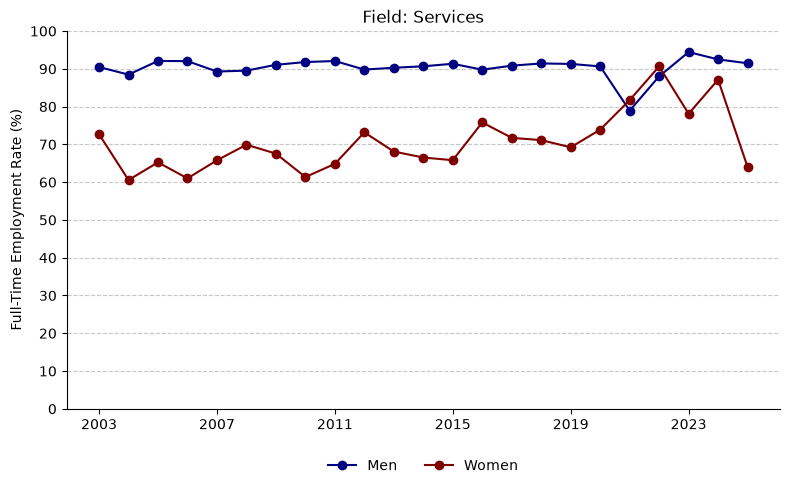

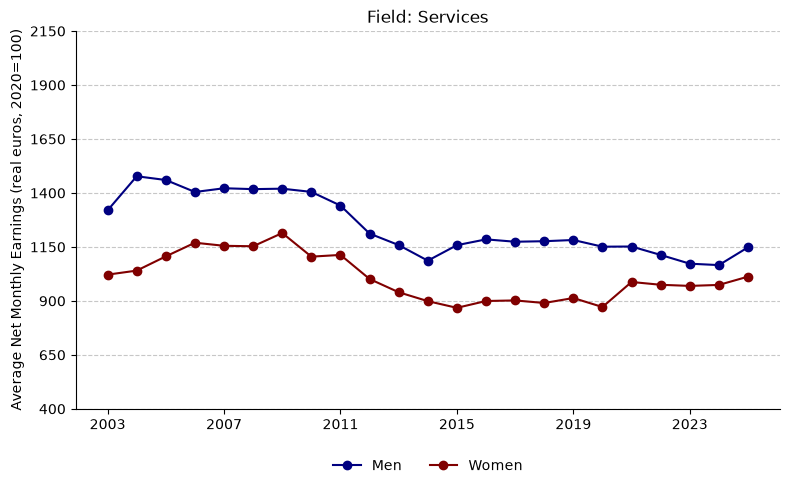

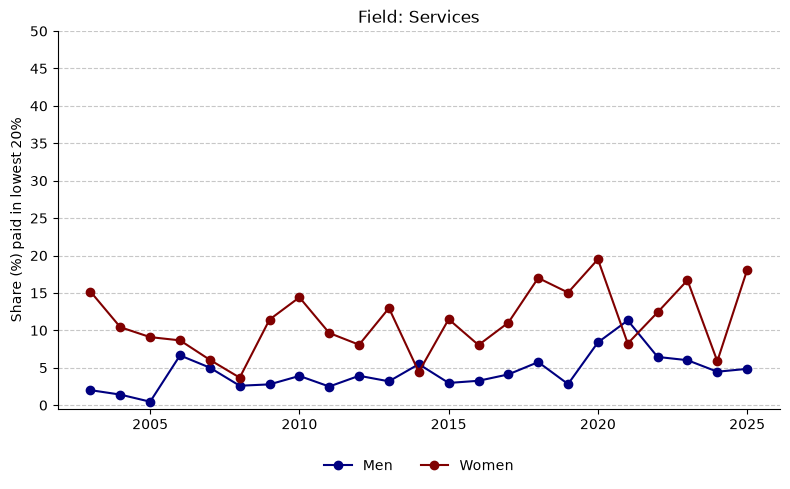

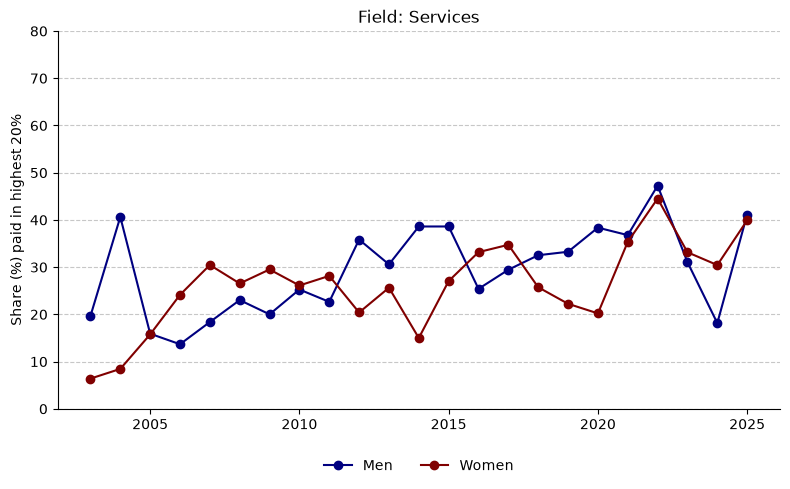

All graphs successfully generated using monthly earnings.


In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Helper function to compute weighted means safely
def weighted_mean(values, weights):
    valid = values.notna() & weights.notna()
    if valid.sum() == 0:
        return np.nan
    return np.average(values[valid], weights=weights[valid])

# Dictionary of all 8 broad academic fields
field_titles = {
    61: "Field: Education",
    62: "Field: Arts and humanities",
    63: "Field: Social sciences, economics and law",
    64: "Field: Natural sciences, math and stats",
    65: "Field: Engineering, manufacturing and construction",
    66: "Field: Agriculture, forestry, fisheries and veterinary",
    67: "Field: Health and welfare",
    68: "Field: Services"
}

# Reusable plotting function for consistent styling
def make_line_plot(data_subset, y_var, y_label, y_ticks, x_ticks, title_text, scale_pct=True):
    agg = []
    for (yr, fem), group in data_subset.groupby(['year', 'female']):
        wm = weighted_mean(group[y_var], group['final_weight'])
        if scale_pct: 
            wm *= 100
        agg.append({'year': yr, 'female': fem, 'val': wm})
    
    p_df = pd.DataFrame(agg)
    men = p_df[p_df['female'] == 0].sort_values('year')
    women = p_df[p_df['female'] == 1].sort_values('year')
    
    plt.figure(figsize=(8, 5))
    plt.plot(men['year'], men['val'], marker='o', color='navy', label='Men')
    plt.plot(women['year'], women['val'], marker='o', color='maroon', label='Women')
    plt.title(title_text, fontsize=12)
    plt.ylabel(y_label, fontsize=10)
    plt.xlabel("")
    plt.xticks(x_ticks)
    plt.yticks(y_ticks)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

print("Generating all visualization charts using monthly earnings...")

for code, title in field_titles.items():
    sub_df = df_analysis[df_analysis['edu_field'] == code]
    
    # 1. Labor Force Participation Rate (%) (2015+)
    make_line_plot(
        data_subset=sub_df[sub_df['year'] >= 2015], 
        y_var='inlf', 
        y_label="Labor Force Participation Rate (%)", 
        y_ticks=range(0, 110, 10), 
        x_ticks=[2015, 2017, 2019, 2021, 2023, 2025], 
        title_text=title
    )
    
    # 2. Full-Time Employment Rate (%) (2003+)
    make_line_plot(
        data_subset=sub_df[sub_df['year'] >= 2003], 
        y_var='fulltime', 
        y_label="Full-Time Employment Rate (%)", 
        y_ticks=range(0, 110, 10), 
        x_ticks=range(2003, 2026, 4), 
        title_text=title
    )
    
    # 3. Average Net Monthly Earnings (real euros, 2020=100) (2003+) - Universal
    make_line_plot(
        data_subset=sub_df[sub_df['year'] >= 2003], 
        y_var='salary_cont_real', 
        y_label="Average Net Monthly Earnings (real euros, 2020=100)", 
        y_ticks=range(400, 2250, 250), 
        x_ticks=range(2003, 2026, 4), 
        title_text=title, 
        scale_pct=False
    )
    
    # 4. Wage Inequality: Share (%) paid in lowest 20% (2003+)
    make_line_plot(
        data_subset=sub_df[sub_df['year'] >= 2003], 
        y_var='ineq20D', 
        y_label="Share (%) paid in lowest 20%", 
        y_ticks=range(0, 55, 5), 
        x_ticks=range(2005, 2026, 5), 
        title_text=title
    )
    
    # 5. Wage Inequality: Share (%) paid in highest 20% (2003+)
    make_line_plot(
        data_subset=sub_df[sub_df['year'] >= 2003], 
        y_var='ineq80D', 
        y_label="Share (%) paid in highest 20%", 
        y_ticks=range(0, 90, 10), 
        x_ticks=range(2005, 2026, 5), 
        title_text=title
    )

print("All graphs successfully generated using monthly earnings.")

In [44]:
import gc
from types import SimpleNamespace
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd

for var_name in ['res_inlf', 'res_empl', 'res_unem', 'res_hours', 'res_wage', 'res_lwr', 'res_ineq20', 'res_ineq80', 'all_results']:
    if var_name in globals():
        del globals()[var_name]
gc.collect()

df_analysis.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Running OLS regressions with robust standard errors and appropriate survey weights...")

def extract_light_results(fitted_model):
    """Keeps only the table numbers and frees gigabytes of matrix RAM."""
    light = SimpleNamespace(
        params=fitted_model.params.copy(),
        bse=fitted_model.bse.copy(),
        tvalues=fitted_model.tvalues.copy(),
        pvalues=fitted_model.pvalues.copy(),
        nobs=fitted_model.nobs,
        rsquared=fitted_model.rsquared
    )
    del fitted_model
    gc.collect()
    return light

def run_regression_suite(dep_var, weight_col, year_spec="C(year)", extra_controls="+ C(female)"):
    """Helper function to run Pooled, Male-only, and Female-only OLS regressions without filling RAM."""
    models = {}
    
    # Keep only the 7 columns needed for the regression to save memory
    cols_needed = [dep_var, weight_col, 'edu_field', 'age', 'female', 'nuts2', 'year']
    sub_df = df_analysis[cols_needed].dropna()
    
    # Pooled Model
    f_pool = f"{dep_var} ~ C(edu_field, Treatment(reference=40)) + age + I(age**2) {extra_controls} + C(nuts2) + {year_spec}"
    fit_p = smf.wls(f_pool, data=sub_df, weights=sub_df[weight_col]).fit(cov_type='HC1')
    models['Pooled'] = extract_light_results(fit_p)
    
    # Males Only (female == 0)
    df_m = sub_df[sub_df['female'] == 0]
    f_m = f"{dep_var} ~ C(edu_field, Treatment(reference=40)) + age + I(age**2) + C(nuts2) + {year_spec}"
    fit_m = smf.wls(f_m, data=df_m, weights=df_m[weight_col]).fit(cov_type='HC1')
    models['Males'] = extract_light_results(fit_m)
    del df_m
    
    # Females Only (female == 1)
    df_f = sub_df[sub_df['female'] == 1]
    f_f = f"{dep_var} ~ C(edu_field, Treatment(reference=40)) + age + I(age**2) + C(nuts2) + {year_spec}"
    fit_f = smf.wls(f_f, data=df_f, weights=df_f[weight_col]).fit(cov_type='HC1')
    models['Females'] = extract_light_results(fit_f)
    del df_f, sub_df
    gc.collect()
    
    print(f"  Finished {dep_var} (Pooled, Males, Females)")
    return models

# ==============================================================================
# ESTIMATE ALL 24 REGRESSION MODELS
# ==============================================================================
res_inlf = run_regression_suite('inlf', weight_col='final_weight', year_spec="C(year)", extra_controls="+ C(female)")
res_empl = run_regression_suite('empl', weight_col='final_weight', year_spec="C(year)", extra_controls="+ C(female)")
res_unem = run_regression_suite('unem', weight_col='final_weight', year_spec="C(year)", extra_controls="+ C(female)")
res_hours = run_regression_suite('hours', weight_col='final_weight', year_spec="C(year)", extra_controls="+ C(female)")
res_wage = run_regression_suite('wageearner', weight_col='final_weight', year_spec="C(year)", extra_controls="+ C(female)")
res_lwr = run_regression_suite('lwr', weight_col='weightq', year_spec="C(year, Treatment(reference=2018))", extra_controls="+ C(female)")
res_ineq20 = run_regression_suite('ineq20D', weight_col='weightq', year_spec="C(year)", extra_controls="+ C(female)")
res_ineq80 = run_regression_suite('ineq80D', weight_col='weightq', year_spec="C(year)", extra_controls="+ C(female)")

print("\n All 24 OLS regression models successfully executed. Printing tables below...\n")

# ==============================================================================
# DISPLAY ALL 24 REGRESSION TABLES
# ==============================================================================
all_results = {
    '1. Labor Force Participation (inlf)': res_inlf,
    '2. Employment (empl)': res_empl,
    '3. Unemployment (unem)': res_unem,
    '4. Working Hours (hours)': res_hours,
    '5. Wage Earner Status (wageearner)': res_wage,
    '6. Log Real Monthly Earnings (lwr)': res_lwr,
    '7. Inequality Bottom 20% (ineq20D)': res_ineq20,
    '8. Inequality Top 20% (ineq80D)': res_ineq80
}

for outcome_name, suite in all_results.items():
    print("=" * 80)
    print(f"OUTCOME: {outcome_name}")
    print("=" * 80)
    
    for group_name in ['Pooled', 'Males', 'Females']:
        model = suite[group_name]
        print(f"\n--- {outcome_name} | Sample: {group_name} (N = {int(model.nobs)}, R2 = {model.rsquared:.4f}) ---")
        
        table_df = pd.DataFrame({
            'Coefficient': model.params,
            'Robust SE': model.bse,
            't-stat': model.tvalues,
            'P>|t|': model.pvalues
        })
        display(table_df.round(5))

Running OLS regressions with robust standard errors and appropriate survey weights...
  Finished inlf (Pooled, Males, Females)
  Finished empl (Pooled, Males, Females)
  Finished unem (Pooled, Males, Females)
  Finished hours (Pooled, Males, Females)
  Finished wageearner (Pooled, Males, Females)
  Finished lwr (Pooled, Males, Females)
  Finished ineq20D (Pooled, Males, Females)
  Finished ineq80D (Pooled, Males, Females)

 All 24 OLS regression models successfully executed. Printing tables below...

OUTCOME: 1. Labor Force Participation (inlf)

--- 1. Labor Force Participation (inlf) | Sample: Pooled (N = 2074587, R2 = 0.1337) ---


,Coefficient,Robust SE,t-stat,P>|t|
Intercept,0.24088,0.00728,33.07756,0.00000
"C(edu_field, Treatment(reference=40))[T.10.0]",-0.33535,0.00395,-84.85682,0.00000
"C(edu_field, Treatment(reference=40))[T.20.0]",-0.05858,0.00094,-62.10723,0.00000
"C(edu_field, Treatment(reference=40))[T.30.0]",-0.02239,0.00098,-22.86264,0.00000
"C(edu_field, Treatment(reference=40))[T.50.0]",0.08405,0.00101,83.61585,0.00000
"C(edu_field, Treatment(reference=40))[T.61.0]",0.18750,0.00164,114.53700,0.00000
"C(edu_field, Treatment(reference=40))[T.62.0]",0.14382,0.00157,91.32689,0.00000
"C(edu_field, Treatment(reference=40))[T.63.0]",0.11721,0.00105,111.80382,0.00000
"C(edu_field, Treatment(reference=40))[T.64.0]",0.09777,0.00155,63.08387,0.00000
"C(edu_field, Treatment(reference=40))[T.65.0]",0.08517,0.00110,77.48566,0.00000



--- 1. Labor Force Participation (inlf) | Sample: Males (N = 1020061, R2 = 0.0462) ---


,Coefficient,Robust SE,t-stat,P>|t|
Intercept,0.15635,0.00849,18.42424,0.00000
"C(edu_field, Treatment(reference=40))[T.10.0]",-0.34451,0.00567,-60.72168,0.00000
"C(edu_field, Treatment(reference=40))[T.20.0]",-0.01712,0.00091,-18.70750,0.00000
"C(edu_field, Treatment(reference=40))[T.30.0]",0.00620,0.00087,7.12081,0.00000
"C(edu_field, Treatment(reference=40))[T.50.0]",0.03161,0.00096,32.92773,0.00000
"C(edu_field, Treatment(reference=40))[T.61.0]",0.04244,0.00200,21.27237,0.00000
"C(edu_field, Treatment(reference=40))[T.62.0]",0.01775,0.00225,7.88713,0.00000
"C(edu_field, Treatment(reference=40))[T.63.0]",0.02793,0.00111,25.23399,0.00000
"C(edu_field, Treatment(reference=40))[T.64.0]",0.02269,0.00161,14.13332,0.00000
"C(edu_field, Treatment(reference=40))[T.65.0]",0.03147,0.00102,30.98780,0.00000



--- 1. Labor Force Participation (inlf) | Sample: Females (N = 1054526, R2 = 0.0960) ---


...

,Coefficient,Robust SE,t-stat,P>|t|
Intercept,-0.28212,0.01045,-27.00578,0.00000
"C(edu_field, Treatment(reference=40))[T.10.0]",-0.05307,0.00529,-10.03499,0.00000
"C(edu_field, Treatment(reference=40))[T.20.0]",-0.07323,0.00104,-70.12823,0.00000
"C(edu_field, Treatment(reference=40))[T.30.0]",-0.04465,0.00107,-41.76676,0.00000
"C(edu_field, Treatment(reference=40))[T.50.0]",0.03458,0.00145,23.80021,0.00000
"C(edu_field, Treatment(reference=40))[T.61.0]",0.13977,0.00272,51.45753,0.00000
"C(edu_field, Treatment(reference=40))[T.62.0]",0.13220,0.00259,51.13376,0.00000
"C(edu_field, Treatment(reference=40))[T.63.0]",0.22123,0.00212,104.11510,0.00000
"C(edu_field, Treatment(reference=40))[T.64.0]",0.17316,0.00326,53.14078,0.00000
"C(edu_field, Treatment(reference=40))[T.65.0]",0.20939,0.00296,70.71710,0.00000



--- 8. Inequality Top 20% (ineq80D) | Sample: Males (N = 398438, R2 = 0.1457) ---


,Coefficient,Robust SE,t-stat,P>|t|
Intercept,-0.20095,0.01362,-14.75816,0.00000
"C(edu_field, Treatment(reference=40))[T.10.0]",-0.05648,0.00458,-12.31941,0.00000
"C(edu_field, Treatment(reference=40))[T.20.0]",-0.05928,0.00135,-44.05343,0.00000
"C(edu_field, Treatment(reference=40))[T.30.0]",-0.03825,0.00138,-27.81391,0.00000
"C(edu_field, Treatment(reference=40))[T.50.0]",0.03614,0.00222,16.31298,0.00000
"C(edu_field, Treatment(reference=40))[T.61.0]",0.04872,0.00470,10.37254,0.00000
"C(edu_field, Treatment(reference=40))[T.62.0]",0.04610,0.00508,9.08190,0.00000
"C(edu_field, Treatment(reference=40))[T.63.0]",0.20589,0.00325,63.28445,0.00000
"C(edu_field, Treatment(reference=40))[T.64.0]",0.13584,0.00402,33.75160,0.00000
"C(edu_field, Treatment(reference=40))[T.65.0]",0.18908,0.00339,55.78230,0.00000



--- 8. Inequality Top 20% (ineq80D) | Sample: Females (N = 324299, R2 = 0.1693) ---


,Coefficient,Robust SE,t-stat,P>|t|
Intercept,-0.38679,0.01617,-23.92618,0.00000
"C(edu_field, Treatment(reference=40))[T.10.0]",-0.05543,0.01677,-3.30499,0.00095
"C(edu_field, Treatment(reference=40))[T.20.0]",-0.10282,0.00163,-63.23366,0.00000
"C(edu_field, Treatment(reference=40))[T.30.0]",-0.06064,0.00168,-36.07664,0.00000
"C(edu_field, Treatment(reference=40))[T.50.0]",0.03992,0.00192,20.83435,0.00000
"C(edu_field, Treatment(reference=40))[T.61.0]",0.17752,0.00322,55.08891,0.00000
"C(edu_field, Treatment(reference=40))[T.62.0]",0.16598,0.00298,55.77971,0.00000
"C(edu_field, Treatment(reference=40))[T.63.0]",0.24183,0.00280,86.32133,0.00000
"C(edu_field, Treatment(reference=40))[T.64.0]",0.23935,0.00543,44.08964,0.00000
"C(edu_field, Treatment(reference=40))[T.65.0]",0.26806,0.00597,44.89438,0.00000
